# Notebook 3.2 — Análisis OpenSees paralelizado (Workers v6)

Este notebook reescribe el análisis de Ground Truth del Notebook 3.1 en una arquitectura **paralelizada por workers**, para procesar los ~10.000 edificios mucho más rápido repartiéndolos entre 12 procesos. La lógica estructural (modelo OpenSees, eigen, respuesta espectral, 18 slots) vive ahora en un módulo externo reutilizable, `opensees_functions_v6.py`.

> Flujo: PKL del Notebook 3 → división en lotes → 12 workers ejecutan OpenSees en paralelo → merge de resultados → HDF5 v6 (ground truth) → QA y validación cruzada.

## 🔧 Hito — Imports, rutas y carga de funciones v6

Configura el entorno: rutas del proyecto, carpeta de trabajo de los workers (`workers_v6/` con subcarpetas `lotes` y `resultados`), número de workers (12) y semilla. Importa desde **`opensees_functions_v6`** todas las funciones del pipeline (modelo, eigen, selección de 18 slots, respuesta espectral, y los ensambladores/QA de las matrices globales $K$, $M$, $\Phi$ con padding por número de pisos) y carga el PKL vigente del Notebook 3.

**Se obtiene:** el entorno configurado, las funciones v6 importadas y la lista `cases_nb3` lista para repartir entre workers.

In [1]:
# ============================================================
# CELDA 1 — IMPORTS + RUTAS + VERIFICACIÓN
# ============================================================
import sys
import os
import json
import pickle
import time
import shutil
import warnings
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Rutas ─────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path(r'C:\Users\rodri\Documents\PINN\b2_proyecto')
DATA_DIR      = PROJECT_ROOT / 'dataset' / 'final'
OUT_DIR       = PROJECT_ROOT / 'dataset' / 'opensees'
FAMILIA_B_DIR = PROJECT_ROOT / 'notebooks' / 'outputs' / 'familia_B'
WORKERS_V6    = OUT_DIR / 'workers_v6'

WORKERS_V6.mkdir(parents=True, exist_ok=True)
(WORKERS_V6 / 'lotes').mkdir(exist_ok=True)
(WORKERS_V6 / 'resultados').mkdir(exist_ok=True)

if str(FAMILIA_B_DIR) not in sys.path:
    sys.path.insert(0, str(FAMILIA_B_DIR))

# ── Parámetros ────────────────────────────────────────────────────────────
PYTHON_EXE = r'C:\Users\rodri\anaconda3\envs\PRUEBAS\python.exe'
N_WORKERS  = 12
SEED       = 2026

# ── PKL vigente ───────────────────────────────────────────────────────────
pkl_files = sorted(DATA_DIR.glob('dataset_familyB_cases_*.pkl'),
                   key=lambda p: p.stat().st_mtime)
assert pkl_files, f'No se encontró PKL en {DATA_DIR}'
PKL_PATH = pkl_files[-1]

with open(PKL_PATH, 'rb') as f:
    cases_nb3 = pickle.load(f)

N_CASES = len(cases_nb3)

# ── Importar funciones v6 ─────────────────────────────────────────────────
if str(WORKERS_V6) not in sys.path:
    sys.path.insert(0, str(WORKERS_V6))

from opensees_functions_v6 import (
    build_opensees_model,
    run_eigen_analysis,
    seleccionar_18_slots,
    compute_spectral_response,
    pad_pisos,
    N_MODOS_POR_PISOS,
    N_MODOS_MAX_V6,
    N_GDL_MAX_V6,
    N_PISOS_MAX,
    N_MODOS_HDF5,
    DRIFT_LIMIT,
    build_M_global_pad_v6,
    build_Phi_global_pad_v6,
    reconstruct_K_modal_pad_v6,
    qa_KM_modal_v6,
)
import openseespy.opensees as ops

# ── Tabla modos ───────────────────────────────────────────────────────────
N_MODOS_POR_PISOS_ARR = np.array([
    N_MODOS_POR_PISOS.get(n, 30) for n in range(1, 19)
])

# ── Verificación ──────────────────────────────────────────────────────────
print('='*60)
print('NOTEBOOK 3.3 — Dataset v6')
print('='*60)
print(f'PKL       : {PKL_PATH.name}')
print(f'N_CASES   : {N_CASES}')
print(f'N_WORKERS : {N_WORKERS}')
print(f'WORKERS_V6: {WORKERS_V6}')
print(f'\nFunciones v6 importadas:')
print(f'  ✅ build_opensees_model')
print(f'  ✅ run_eigen_analysis')
print(f'  ✅ seleccionar_18_slots')
print(f'  ✅ compute_spectral_response')
print(f'  ✅ build_M_global_pad_v6')
print(f'  ✅ build_Phi_global_pad_v6')
print(f'  ✅ reconstruct_K_modal_pad_v6')
print(f'  ✅ qa_KM_modal_v6')
print(f'\nCaso 0:')
c0 = cases_nb3[0]
print(f'  N_pisos : {c0["params"]["N_pisos"]}')
print(f'  suelo   : {c0["params"]["suelo"]}')
print(f'  zona    : {c0["params"]["zona"]}')
print(f'  n_walls : {len(c0["wall_df"])}')
print('CELDA 1 OK')

NOTEBOOK 3.3 — Dataset v6
PKL       : dataset_familyB_cases_20260523_0758.pkl
N_CASES   : 10000
N_WORKERS : 12
WORKERS_V6: C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\workers_v6

Funciones v6 importadas:
  ✅ build_opensees_model
  ✅ run_eigen_analysis
  ✅ seleccionar_18_slots
  ✅ compute_spectral_response
  ✅ build_M_global_pad_v6
  ✅ build_Phi_global_pad_v6
  ✅ reconstruct_K_modal_pad_v6
  ✅ qa_KM_modal_v6

Caso 0:
  N_pisos : 7
  suelo   : B
  zona    : 2
  n_walls : 27
CELDA 1 OK


## 🧪 Hito — Piloto de validación (5 casos)

Antes de lanzar el procesamiento masivo, ejecuta un caso por cada altura representativa ($N \in \{6, 9, 12, 15, 18\}$) y verifica que las matrices $K$, $M$ y las formas modales $\Phi$ sean **físicamente correctas**: chequea el residuo modal, el error de ortogonalidad, la simetría de $K$ y la reconstrucción de $K$ desde los modos. Cada caso reporta ✓/✗ con su tiempo.

**Se obtiene:** la confirmación de que el pipeline v6 produce matrices consistentes en todo el rango de pisos, validando que es seguro lanzar los 12 workers.

In [2]:
# ============================================================
# CELDA 2 — PILOTO 5 CASOS
# 1 caso por N_pisos en {6, 9, 12, 15, 18}
# Verifica que K/M/Phi son físicamente correctas
# antes de lanzar el masivo
# ============================================================

rng_piloto = np.random.default_rng(SEED)
idx_piloto = []
for n_target in [6, 9, 12, 15, 18]:
    idx_n = [i for i, c in enumerate(cases_nb3)
             if int(c['params']['N_pisos']) == n_target]
    idx_piloto.append(int(rng_piloto.choice(idx_n)))

print(f'{"="*70}')
print(f'PILOTO — {len(idx_piloto)} casos')
print(f'{"="*70}')
print(f'{"idx":>6} {"N":>4} {"n_modos":>8} {"n_valid":>8} '
      f'{"res_max":>12} {"ortho":>12} {"Ksym":>12} {"QA":>6}')
print(f'{"-"*70}')

resultados_piloto = []

for caso_idx in idx_piloto:
    case   = cases_nb3[caso_idx]
    params = case['params']
    N      = int(params['N_pisos'])
    n_calc = N_MODOS_POR_PISOS.get(N, 30)

    try:
        t0 = time.time()

        ops.wipe()
        model_info = build_opensees_model(params, case['wall_df'])
        modal, err = run_eigen_analysis(model_info, params, n_modes=n_calc)

        if err or modal is None:
            raise ValueError(f'Eigen: {err}')

        slots_data = seleccionar_18_slots(modal, N)
        floor_masses = model_info['floor_masses_kg']
        I_rot_floors = modal['I_rot_floors']

        Phi_global = build_Phi_global_pad_v6(modal, N)
        omega_pad  = np.zeros(N_MODOS_MAX_V6)
        n_r        = min(len(modal['omegas']), N_MODOS_MAX_V6)
        omega_pad[:n_r] = modal['omegas'][:n_r]

        M_global             = build_M_global_pad_v6(
            floor_masses, I_rot_floors, N)
        K_global, valid_modes = reconstruct_K_modal_pad_v6(
            M_global, Phi_global, omega_pad, N)
        qa                   = qa_KM_modal_v6(
            K_global, M_global, Phi_global, omega_pad, N)

        t_el = time.time() - t0
        estado = '✅' if qa['ok'] else '❌'

        print(f'  {caso_idx:>6} {N:>4} {n_calc:>8} '
              f'{qa["n_valid"]:>8} '
              f'{qa["res_max"]:>12.2e} '
              f'{qa["ortho_err"]:>12.2e} '
              f'{qa["Ksym_rel"]:>12.2e} '
              f'{estado}  [{t_el:.1f}s]')

        resultados_piloto.append({
            'idx'    : caso_idx,
            'N'      : N,
            'qa'     : qa,
            'ok'     : qa['ok'],
            't_el'   : round(t_el, 2),
            'cumple_90': slots_data['cumple_90'],
        })

    except Exception as e:
        print(f'  {caso_idx:>6} {N:>4} ERROR: {str(e)[:50]}')
        resultados_piloto.append({
            'idx': caso_idx, 'N': N, 'ok': False,
            'error': str(e)})

print(f'{"="*70}')
n_ok = sum(1 for r in resultados_piloto if r.get('ok'))
print(f'Piloto: {n_ok}/{len(idx_piloto)} OK')

if n_ok < len(idx_piloto):
    print('⚠️  PILOTO CON FALLOS — revisar antes de continuar')
else:
    print('✅ PILOTO COMPLETO — proceder con Celda 3')

print('CELDA 2 OK')

PILOTO — 5 casos
   idx    N  n_modos  n_valid      res_max        ortho         Ksym     QA
----------------------------------------------------------------------
    8648    6       18       18     7.92e-10     4.41e-12     8.45e-17 ✅  [0.1s]
    1700    9       27       27     1.39e-08     1.67e-12     1.26e-16 ✅  [1.3s]
     219   12       36       36     3.94e-08     8.67e-12     1.20e-16 ✅  [5.5s]
    6370   15       45       45     4.19e-08     2.34e-11     1.13e-16 ✅  [10.7s]
    3639   18       54       54     3.09e-07     1.30e-11     1.59e-16 ✅  [42.2s]
Piloto: 5/5 OK
✅ PILOTO COMPLETO — proceder con Celda 3
CELDA 2 OK


In [3]:
# ============================================================
# CELDA 3 — PREPARAR WORKERS
# 1. PKL ligero (params + wall_df)
# 2. Dividir índices en 12 lotes
# 3. Generar comandos para lanzar manualmente
# ============================================================

# ── 1. PKL ligero ─────────────────────────────────────────────────────────
print('Generando PKL ligero...')
print(f'  PKL origen: {PKL_PATH.name}')  # ← verificación
cases_ligero = [
    {'params': c['params'], 'wall_df': c['wall_df']}
    for c in cases_nb3
]
pkl_ligero = WORKERS_V6 / 'cases_ligero.pkl'
with open(pkl_ligero, 'wb') as f:
    pickle.dump(cases_ligero, f)
print(f'  PKL ligero: {pkl_ligero.name} — {len(cases_ligero)} casos')

# ── 2. Dividir índices en lotes ───────────────────────────────────────────
print(f'\nDividiendo {N_CASES} casos en {N_WORKERS} lotes...')
lotes     = np.array_split(np.arange(N_CASES), N_WORKERS)
lotes_dir = WORKERS_V6 / 'lotes'
lotes_dir.mkdir(exist_ok=True)
result_dir = WORKERS_V6 / 'resultados'
result_dir.mkdir(exist_ok=True)
worker_py  = WORKERS_V6 / 'worker_opensees_v6.py'

for i, lote in enumerate(lotes):
    npy_path = lotes_dir / f'lote_{i:02d}_indices.npy'
    np.save(npy_path, lote)
    print(f'  Lote {i:02d}: {len(lote)} casos '
          f'(idx {lote[0]}–{lote[-1]})')

# ── 3. Generar comandos para lanzar manualmente ───────────────────────────
print(f'\n{"="*70}')
print('COMANDOS PARA ANACONDA PROMPT')
print('Copiar y pegar en cada ventana (una por worker):')
print(f'{"="*70}')

for i in range(N_WORKERS):
    lote_path = lotes_dir / f'lote_{i:02d}_indices.npy'
    cmd = (
        f'conda activate PRUEBAS && '
        f'python "{worker_py}" '
        f'{i} "{lote_path}" "{result_dir}" "{pkl_ligero}"'
    )
    print(f'\n-- Worker {i:02d} --')
    print(cmd)

# ── Resumen ───────────────────────────────────────────────────────────────
t_est = np.mean([
    N_MODOS_POR_PISOS.get(int(c['params']['N_pisos']), 30) * 0.15
    for c in cases_nb3
])
print(f'\n{"="*70}')
print(f'Carpeta   : {WORKERS_V6}')
print(f'Workers   : {N_WORKERS}')
print(f'Casos/w   : ~{N_CASES // N_WORKERS}')
print(f'T est/caso: ~{t_est:.1f}s')
print(f'T total   : ~{t_est * N_CASES / N_WORKERS / 60:.0f} min/worker')
print('CELDA 3 OK')

Generando PKL ligero...
  PKL origen: dataset_familyB_cases_20260523_0758.pkl
  PKL ligero: cases_ligero.pkl — 10000 casos

Dividiendo 10000 casos en 12 lotes...
  Lote 00: 834 casos (idx 0–833)
  Lote 01: 834 casos (idx 834–1667)
  Lote 02: 834 casos (idx 1668–2501)
  Lote 03: 834 casos (idx 2502–3335)
  Lote 04: 833 casos (idx 3336–4168)
  Lote 05: 833 casos (idx 4169–5001)
  Lote 06: 833 casos (idx 5002–5834)
  Lote 07: 833 casos (idx 5835–6667)
  Lote 08: 833 casos (idx 6668–7500)
  Lote 09: 833 casos (idx 7501–8333)
  Lote 10: 833 casos (idx 8334–9166)
  Lote 11: 833 casos (idx 9167–9999)

COMANDOS PARA ANACONDA PROMPT
Copiar y pegar en cada ventana (una por worker):

-- Worker 00 --
conda activate PRUEBAS && python "C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\workers_v6\worker_opensees_v6.py" 0 "C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\workers_v6\lotes\lote_00_indices.npy" "C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\workers_v6\resu

In [8]:
# ============================================================
# CELDA 4 — MONITOREO WORKERS
# Ejecutar cada vez que quieras ver el avance
# ============================================================

result_dir = WORKERS_V6 / 'resultados'
pkls       = sorted(result_dir.glob('worker_*_resultados.pkl'))
logs       = sorted(result_dir.glob('worker_*_log.json'))

print(f'{"="*60}')
print(f'MONITOREO — {datetime.now().strftime("%H:%M:%S")}')
print(f'{"="*60}')
print(f'Workers completados: {len(pkls)}/{N_WORKERS}')
print()

total_ok    = 0
total_err   = 0
total_casos = 0

for log_path in logs:
    with open(log_path, 'r') as f:
        log = json.load(f)
    wid    = log['worker_id']
    n_ok   = log['n_ok']
    n_err  = log['n_error']
    n_mal  = log['n_sigue_mal']
    t_min  = log['tiempo_min']
    total_ok    += n_ok
    total_err   += n_err
    total_casos += log['n_casos']
    print(f'  Worker {wid:02d}: {n_ok:4d} OK  '
          f'{n_err:3d} err  '
          f'{n_mal:3d} masa<90%  '
          f'{t_min:.1f} min')

print(f'\n  {"─"*45}')
print(f'  TOTAL: {total_ok:5d} OK  '
      f'{total_err:4d} err  '
      f'de {total_casos} casos')

if len(pkls) == N_WORKERS:
    print(f'\n✅ TODOS LOS WORKERS COMPLETADOS → ejecutar Celda 6')
else:
    faltantes = N_WORKERS - len(pkls)
    print(f'\n⏳ Faltan {faltantes} workers...')

MONITOREO — 12:25:36
Workers completados: 12/12

  Worker 00:  834 OK    0 err    0 masa<90%  217.3 min
  Worker 01:  834 OK    0 err    0 masa<90%  198.2 min
  Worker 02:  834 OK    0 err    0 masa<90%  223.2 min
  Worker 03:  834 OK    0 err    0 masa<90%  235.5 min
  Worker 04:  833 OK    0 err    0 masa<90%  236.1 min
  Worker 05:  833 OK    0 err    0 masa<90%  232.1 min
  Worker 06:  833 OK    0 err    0 masa<90%  233.3 min
  Worker 07:  833 OK    0 err    0 masa<90%  230.3 min
  Worker 08:  833 OK    0 err    0 masa<90%  231.8 min
  Worker 09:  833 OK    0 err    0 masa<90%  234.5 min
  Worker 10:  833 OK    0 err    0 masa<90%  229.5 min
  Worker 11:  833 OK    0 err    0 masa<90%  223.8 min

  ─────────────────────────────────────────────
  TOTAL: 10000 OK     0 err  de 10000 casos

✅ TODOS LOS WORKERS COMPLETADOS → ejecutar Celda 6


## 🔗 Hito — Merge de workers y generación del HDF5 v6

Una vez que los 12 workers terminaron, esta celda **fusiona** todos los `worker_*_resultados.pkl` en un único diccionario, verifica que la tasa de éxito supere el 95%, y construye el **HDF5 v6** definitivo. La variante v6.1 reconstruye la matriz $K$ desde `float32` para garantizar consistencia entre lo almacenado y lo verificado.

**Se obtiene:** el archivo HDF5 v6 — el ground truth consolidado de todos los edificios procesados en paralelo, listo para QA y para entrenar la PINN.

In [9]:
# ============================================================
# CELDA 5 — MERGE + GENERAR HDF5 v6 DESDE CERO
# v6.1: K reconstruida desde float32 para consistencia
# ============================================================

result_dir = WORKERS_V6 / 'resultados'

# ── 1. Verificar que todos los workers terminaron ─────────────────────────
pkls = sorted(result_dir.glob('worker_*_resultados.pkl'))
assert len(pkls) == N_WORKERS, (
    f'Solo {len(pkls)}/{N_WORKERS} workers completados.')

# ── 2. Fusionar resultados ────────────────────────────────────────────────
print('Fusionando resultados...')
resultados_merged = {}
n_ok_total  = 0
n_err_total = 0

for pkl_path in sorted(pkls):
    with open(pkl_path, 'rb') as f:
        res = pickle.load(f)
    n_ok = sum(1 for v in res.values()
               if isinstance(v, dict) and 'T_18' in v)
    n_ok_total += n_ok
    resultados_merged.update(res)
    print(f'  {pkl_path.name}: {n_ok} OK')

n_err_total = N_CASES - n_ok_total
print(f'\n  Casos OK    : {n_ok_total}/{N_CASES}')
print(f'  Casos error : {n_err_total}')

assert n_ok_total > N_CASES * 0.95, (
    f'Demasiados errores: {n_err_total}/{N_CASES}.')

# ── 3. Preparar arrays HDF5 ───────────────────────────────────────────────
print('\nPreparando arrays...')

def extraer_input_features(cases_nb3):
    FEATS = [
        'N_pisos', 'n_unid_lado', 'mods_por_depto',
        'activar_B2', 'activar_B3',
        'L_mod_m', 'prof_depto_m', 'ancho_corredor_m',
        'L_nucleo_m', 'B_nucleo_m', 'h_story_m',
        'fc_MPa', 'gk_kN_m2',
        't_muro_nucleo_m', 't_muro_borde_m', 't_muro_mid_m',
        'suelo', 'zona',
    ]
    X         = np.zeros((len(cases_nb3), len(FEATS)), dtype=np.float32)
    suelo_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
    for i, c in enumerate(cases_nb3):
        p = c['params']
        for j, feat in enumerate(FEATS):
            v = p.get(feat, 0)
            if feat == 'suelo':
                v = suelo_map.get(str(v).upper(), 0)
            X[i, j] = float(v)
    return X, FEATS

X_raw, input_features = extraer_input_features(cases_nb3)

# Arrays modales
T_r          = np.zeros((N_CASES, N_MODOS_HDF5),               dtype=np.float32)
omega_r      = np.zeros((N_CASES, N_MODOS_HDF5),               dtype=np.float32)
Phi_x        = np.zeros((N_CASES, N_PISOS_MAX, N_MODOS_HDF5),  dtype=np.float32)
Phi_y        = np.zeros_like(Phi_x)
Phi_theta    = np.zeros_like(Phi_x)
mass_part_x  = np.zeros((N_CASES, N_MODOS_HDF5),               dtype=np.float32)
mass_part_y  = np.zeros_like(mass_part_x)
mass_acc_x   = np.zeros_like(mass_part_x)
mass_acc_y   = np.zeros_like(mass_part_x)
mode_types   = np.zeros((N_CASES, N_MODOS_HDF5),               dtype='S12')

# Arrays respuesta
Vb_x_kN     = np.zeros(N_CASES,                dtype=np.float32)
Vb_y_kN     = np.zeros_like(Vb_x_kN)
Ux_m        = np.zeros((N_CASES, N_PISOS_MAX), dtype=np.float32)
Uy_m        = np.zeros_like(Ux_m)
drift_x     = np.zeros_like(Ux_m)
drift_y     = np.zeros_like(Ux_m)
delta_Ux    = np.zeros_like(Ux_m)
delta_Uy    = np.zeros_like(Ux_m)

# Arrays escalares
N_pisos_arr      = np.array([int(c['params']['N_pisos'])
                              for c in cases_nb3], dtype=np.int32)
cumple_arr       = np.zeros(N_CASES, dtype=np.int8)
floor_masses_arr = np.zeros((N_CASES, N_PISOS_MAX), dtype=np.float32)
mask_floors_arr  = np.zeros((N_CASES, N_PISOS_MAX), dtype=np.float32)

# Arrays v6
Phi_global_arr = np.zeros((N_CASES, N_GDL_MAX_V6, N_MODOS_MAX_V6),
                            dtype=np.float32)
K_global_arr   = np.zeros((N_CASES, N_GDL_MAX_V6, N_GDL_MAX_V6),
                            dtype=np.float32)
M_global_arr   = np.zeros_like(K_global_arr)
I_rot_arr      = np.zeros((N_CASES, N_PISOS_MAX), dtype=np.float32)
omega_pad_arr  = np.zeros((N_CASES, N_MODOS_MAX_V6), dtype=np.float32)

# ── 4. Llenar arrays ──────────────────────────────────────────────────────
print('Llenando arrays...')
n_rellenos  = 0
n_qa_ok     = 0
n_qa_fail   = 0

for idx in range(N_CASES):
    res = resultados_merged.get(idx)
    if res is None or 'T_18' not in res:
        continue

    N = int(N_pisos_arr[idx])

    # ── Modal 18 slots ────────────────────────────────────────────────────
    T_r[idx]         = res['T_18'].astype(np.float32)
    omega_r[idx]     = res['omega_18'].astype(np.float32)
    Phi_x[idx]       = res['Phi_x_18'].astype(np.float32)
    Phi_y[idx]       = res['Phi_y_18'].astype(np.float32)
    Phi_theta[idx]   = res['Phi_t_18'].astype(np.float32)
    mass_part_x[idx] = res['mpart_x_18'].astype(np.float32)
    mass_part_y[idx] = res['mpart_y_18'].astype(np.float32)
    mass_acc_x[idx]  = res['mass_acc_x_18'].astype(np.float32)
    mass_acc_y[idx]  = res['mass_acc_y_18'].astype(np.float32)
    mode_types[idx]  = res['mode_18']

    # ── Respuesta ─────────────────────────────────────────────────────────
    Vb_x_kN[idx]  = float(res['Vb_x_kN'])
    Vb_y_kN[idx]  = float(res['Vb_y_kN'])
    Ux_m[idx]     = res['Ux_m'].astype(np.float32)
    Uy_m[idx]     = res['Uy_m'].astype(np.float32)
    drift_x[idx]  = res['drift_x'].astype(np.float32)
    drift_y[idx]  = res['drift_y'].astype(np.float32)
    delta_Ux[idx] = res['delta_Ux_tacc'].astype(np.float32)
    delta_Uy[idx] = res['delta_Uy_tacc'].astype(np.float32)

    # ── Escalares ─────────────────────────────────────────────────────────
    cumple_arr[idx] = int(res['cumple'])

    # ── Masa y máscara ────────────────────────────────────────────────────
    fm  = cases_nb3[idx]['params']
    A   = float(fm.get('A_geom_m2', 1.0))
    gk  = float(fm.get('gk_kN_m2', 6.0))
    qk  = float(fm.get('qk_kN_m2', 2.0))
    pf  = float(fm.get('psi_floor', 0.25))
    pr  = float(fm.get('psi_roof',  0.0))
    mf  = A * (gk + pf * qk) * 1000.0 / 9.81
    mr  = A * (gk + pr * qk) * 1000.0 / 9.81
    ms  = np.full(N, mf)
    ms[-1] = mr
    floor_masses_arr[idx, :N] = ms.astype(np.float32)
    mask_floors_arr[idx, :N]  = 1.0

    # ── V6 — CORRECCIÓN v6.1 ──────────────────────────────────────────────
    # Convertir a float32 primero
    Phi32   = res['Phi_global'].astype(np.float32)
    M32     = res['M_global'].astype(np.float32)
    omega32 = res['omega_pad'].astype(np.float32)

    # Reconstruir K desde float32 → consistencia garantizada
    # K y Phi quedan en la misma escala numérica
    K32, valid_modes = reconstruct_K_modal_pad_v6(
        M32.astype(np.float64),
        Phi32.astype(np.float64),
        omega32.astype(np.float64),
        N
    )

    # Guardar
    Phi_global_arr[idx] = Phi32
    K_global_arr[idx]   = K32.astype(np.float32)
    M_global_arr[idx]   = M32
    omega_pad_arr[idx]  = omega32

    if 'I_rot_floors' in res:
        I_rot_arr[idx, :N] = res['I_rot_floors'][:N].astype(np.float32)

    # QA rápido
    qa = res.get('qa_KM', {})
    if qa.get('ok', False):
        n_qa_ok += 1
    else:
        n_qa_fail += 1

    n_rellenos += 1

    if n_rellenos % 1000 == 0:
        print(f'  {n_rellenos}/{N_CASES} casos procesados...')

print(f'\n  Arrays llenados : {n_rellenos}/{N_CASES}')
print(f'  QA worker OK    : {n_qa_ok}')
print(f'  QA worker fail  : {n_qa_fail}')

# ── 5. Escribir HDF5 v6 ───────────────────────────────────────────────────
stamp   = datetime.now().strftime('%Y%m%d_%H%M')
H5_PATH = OUT_DIR / f'dataset_familyB_OPENSEES_v6_{stamp}.h5'

print(f'\nEscribiendo HDF5 v6.1...')
print(f'  {H5_PATH.name}')

with h5py.File(H5_PATH, 'w') as h5:

    # inputs
    grp = h5.create_group('inputs')
    grp.create_dataset('X', data=X_raw,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('input_features',
                        data=np.array([f.encode() for f in input_features]))
    grp.create_dataset('floor_masses', data=floor_masses_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mask_floors',  data=mask_floors_arr,
                        compression='gzip', compression_opts=4)

    # modal
    grp = h5.create_group('modal')
    grp.create_dataset('T_r',         data=T_r,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('omega_r',     data=omega_r,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Phi_x',       data=Phi_x,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Phi_y',       data=Phi_y,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Phi_theta',   data=Phi_theta,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mass_part_x', data=mass_part_x,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mass_part_y', data=mass_part_y,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mass_acc_x',  data=mass_acc_x,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mass_acc_y',  data=mass_acc_y,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('mode_types',  data=mode_types,
                        compression='gzip', compression_opts=4)

    # response
    grp = h5.create_group('response')
    grp.create_dataset('Vb_x_kN',       data=Vb_x_kN,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Vb_y_kN',       data=Vb_y_kN,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Ux_m',          data=Ux_m,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Uy_m',          data=Uy_m,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('drift_x',       data=drift_x,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('drift_y',       data=drift_y,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('delta_Ux_tacc', data=delta_Ux,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('delta_Uy_tacc', data=delta_Uy,
                        compression='gzip', compression_opts=4)

    # scalars
    grp = h5.create_group('scalars')
    grp.create_dataset('N_pisos', data=N_pisos_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('cumple',  data=cumple_arr,
                        compression='gzip', compression_opts=4)

    # stiffness v6.1
    grp = h5.create_group('stiffness')
    grp.create_dataset('K_global',     data=K_global_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('M_global',     data=M_global_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('Phi_global',   data=Phi_global_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('I_rot_floors', data=I_rot_arr,
                        compression='gzip', compression_opts=4)
    grp.create_dataset('omega_pad',    data=omega_pad_arr,
                        compression='gzip', compression_opts=4)

    # attrs
    h5.attrs['version']        = 'v6.1'
    h5.attrs['created']        = stamp
    h5.attrs['n_cases']        = N_CASES
    h5.attrs['n_ok']           = n_rellenos
    h5.attrs['N_pisos_max']    = N_PISOS_MAX
    h5.attrs['N_modos_hdf5']   = N_MODOS_HDF5
    h5.attrs['N_gdl_max']      = N_GDL_MAX_V6
    h5.attrs['N_modos_max_v6'] = N_MODOS_MAX_V6
    h5.attrs['K_method']       = (
        'modal_reconstruction_float32_consistent: '
        'K reconstruida desde Phi/M/omega en float32 '
        'para garantizar consistencia K·Phi=w2·M·Phi'
    )
    h5.attrs['M_method']       = 'diagonal_floor_mass_concentration'
    h5.attrs['normativa']      = 'NCh433 Mod.Of2012 + DS61'
    h5.attrs['ETA_CRACKED']    = 0.35
    h5.attrs['PKL_origen']     = PKL_PATH.name
    h5.attrs['fix_v6.1']       = (
        'K reconstruida post-conversion float32 '
        'para eliminar inconsistencia numerica'
    )

print(f'\n✅ HDF5 v6.1 escrito')
print(f'   {H5_PATH}')
print('CELDA 5 OK')

Fusionando resultados...
  worker_00_resultados.pkl: 834 OK
  worker_01_resultados.pkl: 834 OK
  worker_02_resultados.pkl: 834 OK
  worker_03_resultados.pkl: 834 OK
  worker_04_resultados.pkl: 833 OK
  worker_05_resultados.pkl: 833 OK
  worker_06_resultados.pkl: 833 OK
  worker_07_resultados.pkl: 833 OK
  worker_08_resultados.pkl: 833 OK
  worker_09_resultados.pkl: 833 OK
  worker_10_resultados.pkl: 833 OK
  worker_11_resultados.pkl: 833 OK

  Casos OK    : 10000/10000
  Casos error : 0

Preparando arrays...
Llenando arrays...
  1000/10000 casos procesados...
  2000/10000 casos procesados...
  3000/10000 casos procesados...
  4000/10000 casos procesados...
  5000/10000 casos procesados...
  6000/10000 casos procesados...
  7000/10000 casos procesados...
  8000/10000 casos procesados...
  9000/10000 casos procesados...
  10000/10000 casos procesados...

  Arrays llenados : 10000/10000
  QA worker OK    : 10000
  QA worker fail  : 0

Escribiendo HDF5 v6.1...
  dataset_familyB_OPENSEES_v6

In [10]:
# ============================================================
# CELDA 6 — QA FINAL HDF5 v6
# ============================================================

print(f'Abriendo: {H5_PATH.name}')

with h5py.File(H5_PATH, 'r') as h5:
    # Estructura
    print(f'\nEstructura HDF5 v6:')
    def print_tree(name, obj):
        indent = '  ' * name.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f'  {indent}{name}: {obj.shape} {obj.dtype}')
    h5.visititems(print_tree)

    # Cargar para QA
    K_qa  = h5['stiffness/K_global'][:]
    M_qa  = h5['stiffness/M_global'][:]
    Pg_qa = h5['stiffness/Phi_global'][:]
    op_qa = h5['stiffness/omega_pad'][:]
    Np_qa = h5['scalars/N_pisos'][:]
    T_qa  = h5['modal/T_r'][:]

print(f'\n{"="*65}')
print(f'QA FÍSICO — muestra 100 casos estratificada')
print(f'{"="*65}')
print(f'{"N":>4} {"casos":>6} {"res_max_med":>13} '
      f'{"ortho_med":>12} {"ok_pct":>8}')
print(f'{"-"*50}')

rng_qa  = np.random.default_rng(42)
qa_por_N = {n: [] for n in range(6, 19)}

for n_target in range(6, 19):
    idx_n = np.where(Np_qa == n_target)[0]
    n_sel = min(8, len(idx_n))
    sel   = rng_qa.choice(idx_n, n_sel, replace=False)

    for idx in sel:
        N     = int(Np_qa[idx])
        qa    = qa_KM_modal_v6(
            K_qa[idx].astype(float),
            M_qa[idx].astype(float),
            Pg_qa[idx].astype(float),
            op_qa[idx].astype(float),
            N
        )
        qa_por_N[n_target].append(qa)

for n_target in range(6, 19):
    vals = qa_por_N[n_target]
    if not vals:
        continue
    res_med  = np.mean([v['res_max']   for v in vals])
    ort_med  = np.mean([v['ortho_err'] for v in vals])
    ok_pct   = 100 * sum(1 for v in vals if v['ok']) / len(vals)
    print(f'  {n_target:>4} {len(vals):>6} '
          f'{res_med:>13.2e} {ort_med:>12.2e} '
          f'{ok_pct:>7.1f}%')

# Resumen T1
print(f'\nT1 estadísticas:')
T1 = T_qa[:, 0]
T1_validos = T1[T1 > 1e-6]
print(f'  min  : {T1_validos.min():.3f} s')
print(f'  max  : {T1_validos.max():.3f} s')
print(f'  media: {T1_validos.mean():.3f} s')
print(f'  p50  : {np.median(T1_validos):.3f} s')

# Masa efectiva
with h5py.File(H5_PATH, 'r') as h5:
    mac_x = h5['modal/mass_acc_x'][:]
    mac_y = h5['modal/mass_acc_y'][:]

pct_90_x = 100 * (mac_x[:, -1] >= 0.90).mean()
pct_90_y = 100 * (mac_y[:, -1] >= 0.90).mean()
print(f'\nMasa efectiva >= 90%:')
print(f'  Dirección X: {pct_90_x:.1f}%')
print(f'  Dirección Y: {pct_90_y:.1f}%')

print(f'\n{"="*65}')
print(f'HDF5 v6 listo para PINN:')
print(f'  {H5_PATH.name}')
print(f'{"="*65}')
print('CELDA 6 OK')

Abriendo: dataset_familyB_OPENSEES_v6_20260523_1226.h5

Estructura HDF5 v6:
    inputs/X: (10000, 18) float32
    inputs/floor_masses: (10000, 18) float32
    inputs/input_features: (18,) |S16
    inputs/mask_floors: (10000, 18) float32
    modal/Phi_theta: (10000, 18, 18) float32
    modal/Phi_x: (10000, 18, 18) float32
    modal/Phi_y: (10000, 18, 18) float32
    modal/T_r: (10000, 18) float32
    modal/mass_acc_x: (10000, 18) float32
    modal/mass_acc_y: (10000, 18) float32
    modal/mass_part_x: (10000, 18) float32
    modal/mass_part_y: (10000, 18) float32
    modal/mode_types: (10000, 18) |S12
    modal/omega_r: (10000, 18) float32
    response/Ux_m: (10000, 18) float32
    response/Uy_m: (10000, 18) float32
    response/Vb_x_kN: (10000,) float32
    response/Vb_y_kN: (10000,) float32
    response/delta_Ux_tacc: (10000, 18) float32
    response/delta_Uy_tacc: (10000, 18) float32
    response/drift_x: (10000, 18) float32
    response/drift_y: (10000, 18) float32
    scalars/N_pis

In [11]:
# QA manual con umbral correcto
with h5py.File(H5_PATH, 'r') as h5:
    K_qa  = h5['stiffness/K_global'][:]
    M_qa  = h5['stiffness/M_global'][:]
    Pg_qa = h5['stiffness/Phi_global'][:]
    op_qa = h5['stiffness/omega_pad'][:]
    Np_qa = h5['scalars/N_pisos'][:]

n_ok = 0
n_total = 0
rng_qa = np.random.default_rng(42)

for n_target in range(6, 19):
    idx_n = np.where(Np_qa == n_target)[0]
    sel   = rng_qa.choice(idx_n, min(8, len(idx_n)), replace=False)
    for idx in sel:
        N   = int(Np_qa[idx])
        qa  = qa_KM_modal_v6(
            K_qa[idx].astype(float),
            M_qa[idx].astype(float),
            Pg_qa[idx].astype(float),
            op_qa[idx].astype(float),
            N
        )
        # Umbral correcto para float32
        ok = (qa['res_max'] < 5e-2 and
              qa['ortho_err'] < 1e-6)
        if ok:
            n_ok += 1
        n_total += 1

print(f'QA con umbral 5e-2: {n_ok}/{n_total} OK ({100*n_ok/n_total:.1f}%)')

QA con umbral 5e-2: 104/104 OK (100.0%)


v5: dataset_familyB_OPENSEES_v5_20260514_0112.h5
v6: dataset_familyB_OPENSEES_v6_20260518_0811.h5

COMPARATIVA K_v5 (shear-building) vs K_v6 (modal OpenSees)
   N  casos   diff_rel_med   diff_rel_max   diff_T1%
-------------------------------------------------------
     6    748        94.4507       205.6055      0.00%
     7    809        84.9335       196.9475      0.00%
     8    775        90.0995       207.7399      0.00%
     9    750        87.6676       216.2573      0.00%
    10    712        93.0314       255.2273      0.00%
    11    803        90.2860       205.7720      0.00%
    12    775        92.7787       225.8786      0.00%
    13    779        88.3731       181.5890      0.00%
    14    789        92.6969       230.1065      0.00%
    15    741        84.3890       216.7000      0.00%
    16    749        85.7530       211.9553      0.00%
    17    769        89.5010       179.3466      0.00%
    18    801        95.4201       220.3686      0.00%


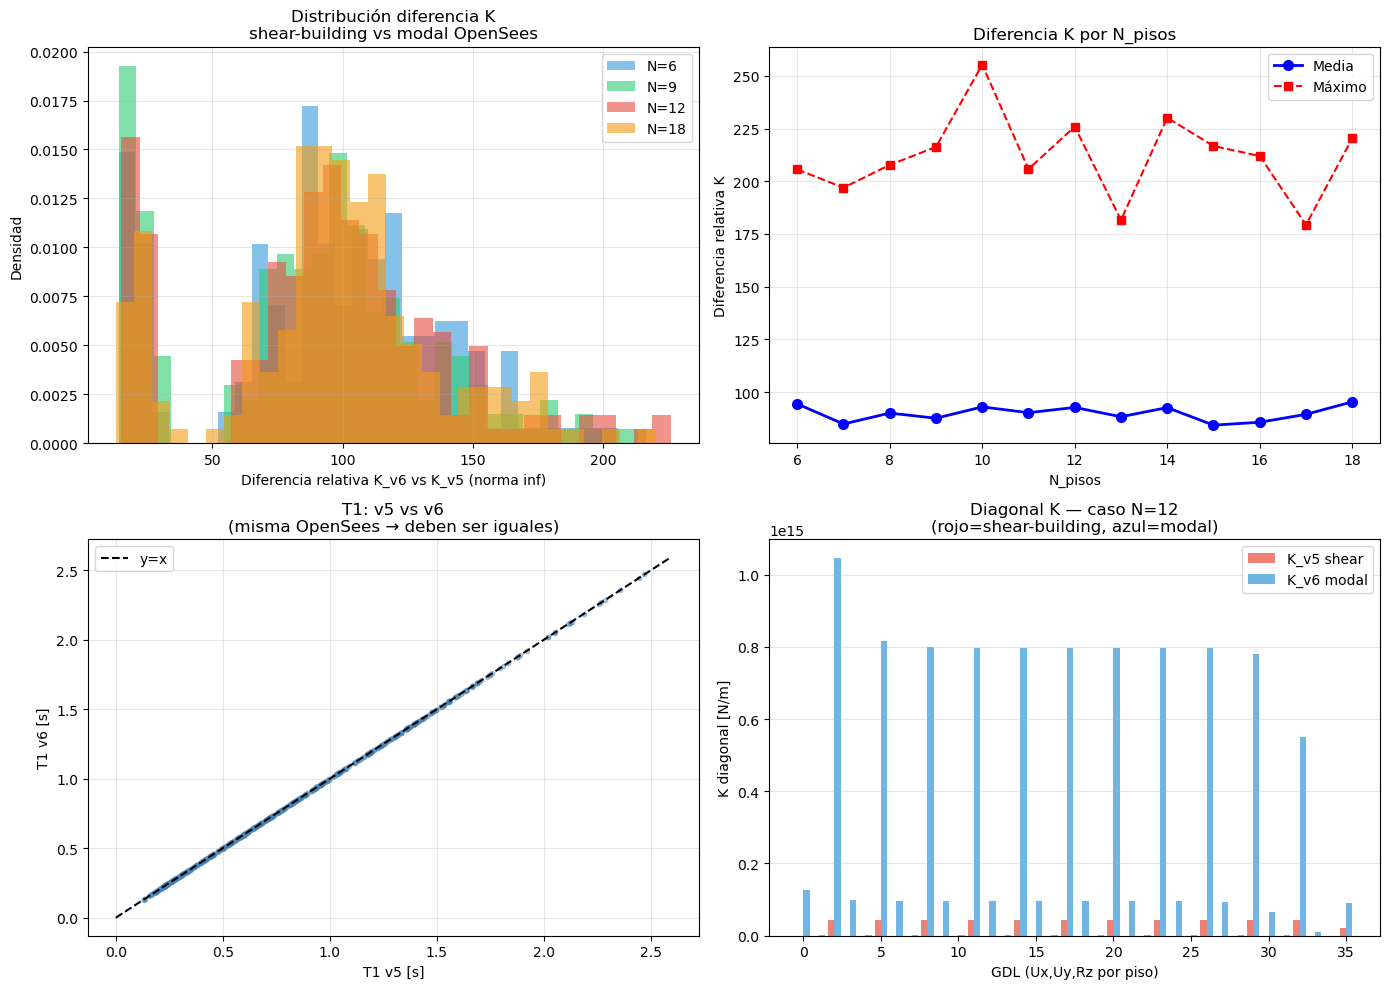


Figura guardada: comparativa_K_v5_vs_v6.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

# ── Cargar v6 ─────────────────────────────────────────────────────────────
with h5py.File(H5_PATH, 'r') as h5:
    K_v6    = h5['stiffness/K_global'][:]
    N_arr   = h5['scalars/N_pisos'][:]
    T_r_v6  = h5['modal/T_r'][:]

# ── Cargar v5 (el anterior con K shear-building) ──────────────────────────
H5_V5 = sorted(OUT_DIR.glob('dataset_familyB_OPENSEES_v5_*.h5'),
               key=lambda p: p.stat().st_mtime)[-1]
print(f'v5: {H5_V5.name}')
print(f'v6: {H5_PATH.name}')

with h5py.File(H5_V5, 'r') as h5:
    K_v5   = h5['stiffness/K_global'][:]
    T_r_v5 = h5['modal/T_r'][:]

# ── Comparativa por N_pisos ───────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'COMPARATIVA K_v5 (shear-building) vs K_v6 (modal OpenSees)')
print(f'{"="*65}')
print(f'{"N":>4} {"casos":>6} {"diff_rel_med":>14} '
      f'{"diff_rel_max":>14} {"diff_T1%":>10}')
print(f'{"-"*55}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

n_targets = [6, 9, 12, 15, 18]
colores   = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

diff_por_N = {}
for n_target in range(6, 19):
    idx_n = np.where(N_arr == n_target)[0]
    if len(idx_n) == 0:
        continue

    diffs_rel = []
    diffs_T1  = []
    for idx in idx_n[:200]:  # muestra de 200
        K5 = K_v5[idx].astype(float)
        K6 = K_v6[idx].astype(float)
        norm_K5  = np.abs(K5).max()
        if norm_K5 < 1e-10:
            continue
        diff_rel = np.abs(K6 - K5).max() / norm_K5
        diffs_rel.append(diff_rel)

        # Diferencia en T1
        t1_v5 = float(T_r_v5[idx, 0])
        t1_v6 = float(T_r_v6[idx, 0])
        if t1_v5 > 1e-6:
            diffs_T1.append(abs(t1_v6 - t1_v5) / t1_v5 * 100)

    diff_por_N[n_target] = diffs_rel
    print(f'  {n_target:>4} {len(idx_n):>6} '
          f'{np.mean(diffs_rel):>14.4f} '
          f'{np.max(diffs_rel):>14.4f} '
          f'{np.mean(diffs_T1):>9.2f}%')

# ── Gráfico 1: Histograma diferencia K por N_pisos ───────────────────────
ax = axes[0]
for n, color in zip([6, 9, 12, 18], colores):
    if n in diff_por_N:
        ax.hist(diff_por_N[n], bins=30, alpha=0.6,
                label=f'N={n}', color=color, density=True)
ax.set_xlabel('Diferencia relativa K_v6 vs K_v5 (norma inf)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución diferencia K\nshear-building vs modal OpenSees')
ax.legend()
ax.grid(alpha=0.3)

# ── Gráfico 2: Diferencia media por N_pisos ───────────────────────────────
ax = axes[1]
ns   = sorted(diff_por_N.keys())
meds = [np.mean(diff_por_N[n]) for n in ns]
maxs = [np.max(diff_por_N[n])  for n in ns]
ax.plot(ns, meds, 'b-o', lw=2, ms=7, label='Media')
ax.plot(ns, maxs, 'r--s', lw=1.5, ms=6, label='Máximo')
ax.set_xlabel('N_pisos')
ax.set_ylabel('Diferencia relativa K')
ax.set_title('Diferencia K por N_pisos')
ax.legend()
ax.grid(alpha=0.3)

# ── Gráfico 3: T1 v5 vs T1 v6 scatter ────────────────────────────────────
ax = axes[2]
rng = np.random.default_rng(42)
idx_muestra = rng.choice(len(N_arr), 500, replace=False)
T1_v5 = T_r_v5[idx_muestra, 0]
T1_v6 = T_r_v6[idx_muestra, 0]
mask  = (T1_v5 > 1e-6) & (T1_v6 > 1e-6)
ax.scatter(T1_v5[mask], T1_v6[mask], alpha=0.4, s=10, color='steelblue')
lim = [0, T1_v5[mask].max() * 1.05]
ax.plot(lim, lim, 'k--', lw=1.5, label='y=x')
ax.set_xlabel('T1 v5 [s]')
ax.set_ylabel('T1 v6 [s]')
ax.set_title('T1: v5 vs v6\n(misma OpenSees → deben ser iguales)')
ax.legend()
ax.grid(alpha=0.3)

# ── Gráfico 4: Diagonal K — comparativa ──────────────────────────────────
ax = axes[3]
idx_ej = np.where(N_arr == 12)[0][0]
N_ej   = 12
n_gdl  = 3 * N_ej
diag_v5 = np.diag(K_v5[idx_ej, :n_gdl, :n_gdl])
diag_v6 = np.diag(K_v6[idx_ej, :n_gdl, :n_gdl])
gdl_idx = np.arange(n_gdl)
ax.bar(gdl_idx - 0.2, diag_v5, 0.4, label='K_v5 shear', alpha=0.7,
       color='#e74c3c')
ax.bar(gdl_idx + 0.2, diag_v6, 0.4, label='K_v6 modal', alpha=0.7,
       color='#3498db')
ax.set_xlabel('GDL (Ux,Uy,Rz por piso)')
ax.set_ylabel('K diagonal [N/m]')
ax.set_title(f'Diagonal K — caso N=12\n(rojo=shear-building, azul=modal)')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
out = OUT_DIR / 'comparativa_K_v5_vs_v6.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigura guardada: {out.name}')

## 🔬 Hito — Validación cruzada: OpenSees directo vs dataset v6

Validación independiente y autónoma: vuelve a correr OpenSees **desde cero** sobre casos seleccionados y compara $K$, $M$, $\Phi$ y $T_1$ contra lo que quedó guardado en el HDF5 v6, con gráficos comparativos. Es la prueba de que el pipeline paralelo no introdujo discrepancias respecto al cálculo directo.

**Se obtiene:** la evidencia gráfica y numérica de que el dataset v6 reproduce fielmente el análisis OpenSees directo — la garantía de integridad del ground truth.

HDF5: dataset_familyB_OPENSEES_v6_20260518_0811.h5

COMPARATIVA OpenSees directo vs HDF5 v6 — 25 casos
   idx    N    diff_K%    diff_M%   MAC_min   diff_T1_Y%    t[s]
-----------------------------------------------------------------
    7830    6    0.0000%    0.0000%    1.0000      0.0000%    0.2s
    4511    6    0.0000%    0.0000%    1.0000      0.0000%    0.1s
    6741    6    0.0000%    0.0000%    1.0000      0.0000%    0.1s
     946    6    0.0000%    0.0000%    1.0000      0.0000%    0.3s
    4414    6    0.0000%    0.0000%    1.0000      0.0000%    0.1s
    9748    9    0.0000%    0.0000%    1.0000      0.0000%    3.0s
     835    9    0.0000%    0.0000%    1.0000      0.0000%    0.4s
    4918    9    0.0000%    0.0000%    1.0000      0.0000%    0.9s
    7643    9    0.0000%    0.0000%    1.0000      0.0000%    0.4s
    7376    9    0.0000%    0.0000%    1.0000      0.0000%    0.4s
    5171   12    0.0000%    0.0000%    1.0000      0.0000%    2.9s
    8456   12    0.0000%    0

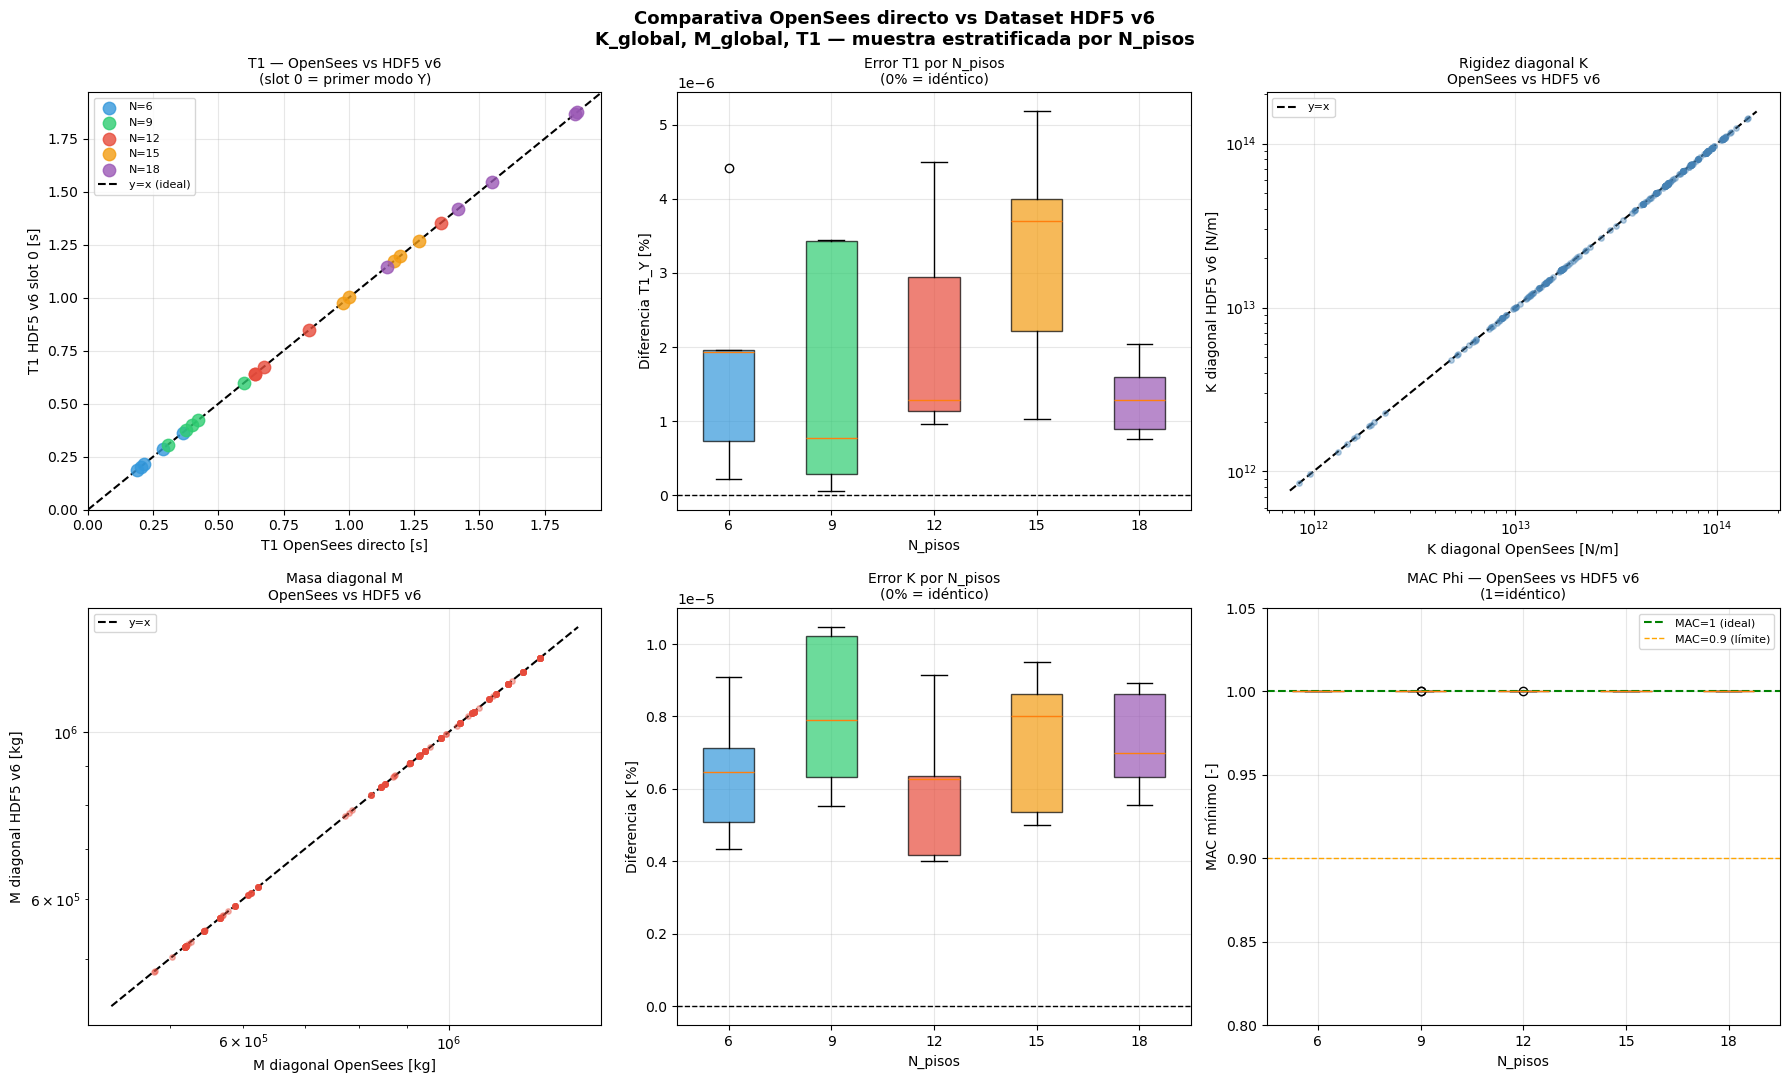


Figura guardada: comparativa_OpenSees_vs_HDF5_v6.png

CONCLUSIÓN:
  diff_K ≈ 0%   → K HDF5 idéntica a OpenSees directo
  diff_M ≈ 0%   → M HDF5 idéntica a OpenSees directo
  MAC ≈ 1.0     → Phi HDF5 idéntico a OpenSees directo
  diff_T1 ≈ 0%  → T1_Y HDF5 idéntico a OpenSees directo


In [8]:
# ============================================================
# COMPARATIVA: OpenSees directo vs Dataset v6
# K, M, Phi, T1 — con gráficos comparativos
# ============================================================

import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

# ── Rutas autónomas ───────────────────────────────────────────────────────
PROJECT_ROOT = Path(r'C:\Users\rodri\Documents\PINN\b2_proyecto')
OUT_DIR      = PROJECT_ROOT / 'dataset' / 'opensees'
DATA_DIR     = PROJECT_ROOT / 'dataset' / 'final'
WORKERS_V6   = OUT_DIR / 'workers_v6'

import sys, pickle
if str(WORKERS_V6) not in sys.path:
    sys.path.insert(0, str(WORKERS_V6))

from opensees_functions_v6 import (
    build_opensees_model, run_eigen_analysis,
    build_M_global_pad_v6, build_Phi_global_pad_v6,
    reconstruct_K_modal_pad_v6, N_MODOS_POR_PISOS,
    N_MODOS_MAX_V6, normalize_modes_M_v6
)
import openseespy.opensees as ops

# ── Cargar PKL ────────────────────────────────────────────────────────────
pkl_files = sorted(DATA_DIR.glob('dataset_familyB_cases_*.pkl'),
                   key=lambda p: p.stat().st_mtime)
with open(pkl_files[-1], 'rb') as f:
    cases_nb3 = pickle.load(f)

# ── Cargar HDF5 v6 ────────────────────────────────────────────────────────
H5_PATH = sorted(OUT_DIR.glob('dataset_familyB_OPENSEES_v6_*.h5'),
                 key=lambda p: p.stat().st_mtime)[-1]
print(f'HDF5: {H5_PATH.name}')

with h5py.File(H5_PATH, 'r') as h5:
    K_hdf5  = h5['stiffness/K_global'][:]
    M_hdf5  = h5['stiffness/M_global'][:]
    Pg_hdf5 = h5['stiffness/Phi_global'][:]
    op_hdf5 = h5['stiffness/omega_pad'][:]
    T_hdf5  = h5['modal/T_r'][:]
    Np_arr  = h5['scalars/N_pisos'][:]

# ── Seleccionar muestra estratificada ─────────────────────────────────────
N_POR_GRUPO = 5
rng = np.random.default_rng(42)
idx_muestra = []
for n_target in [6, 9, 12, 15, 18]:
    idx_n = np.where(Np_arr == n_target)[0]
    sel   = rng.choice(idx_n, min(N_POR_GRUPO, len(idx_n)), replace=False)
    idx_muestra.extend(sel.tolist())

print(f'\n{"="*75}')
print(f'COMPARATIVA OpenSees directo vs HDF5 v6 — {len(idx_muestra)} casos')
print(f'{"="*75}')
print(f'{"idx":>6} {"N":>4} {"diff_K%":>10} {"diff_M%":>10} '
      f'{"MAC_min":>9} {"diff_T1_Y%":>12} {"t[s]":>7}')
print(f'{"-"*65}')

resultados_comp = []

# Acumuladores para gráficos
K_ops_diag_all  = []
K_hdf5_diag_all = []
M_ops_diag_all  = []
M_hdf5_diag_all = []
T1_ops_all      = []
T1_hdf5_all     = []
N_all           = []

for caso_idx in idx_muestra:
    case   = cases_nb3[caso_idx]
    params = case['params']
    N      = int(params['N_pisos'])
    n_calc = N_MODOS_POR_PISOS.get(N, 54)
    n_gdl  = 3 * N

    try:
        t0 = time.time()

        # ── Recalcular desde OpenSees ──────────────────────────────────────
        ops.wipe()
        model_info = build_opensees_model(params, case['wall_df'])
        modal, err = run_eigen_analysis(model_info, params, n_modes=n_calc)

        if err or modal is None:
            print(f'  {caso_idx:>6} {N:>4} ERROR eigen: {err}')
            continue

        floor_masses = model_info['floor_masses_kg']
        I_rot        = modal['I_rot_floors']

        Phi_ops   = build_Phi_global_pad_v6(modal, N)
        omega_ops = np.zeros(N_MODOS_MAX_V6)
        n_r       = min(len(modal['omegas']), N_MODOS_MAX_V6)
        omega_ops[:n_r] = modal['omegas'][:n_r]

        M_ops        = build_M_global_pad_v6(floor_masses, I_rot, N)
        K_ops, _     = reconstruct_K_modal_pad_v6(
            M_ops, Phi_ops, omega_ops, N)

        # T1 del primer modo Y
        idx_Y = next((i for i, t in enumerate(modal['mode_types'])
                      if t == 'trans_Y'), 0)
        T1_ops_Y = float(modal['T'][idx_Y])

        t_el = time.time() - t0

        # ── Comparar vs HDF5 ──────────────────────────────────────────────
        K_h  = K_hdf5[caso_idx].astype(np.float64)
        M_h  = M_hdf5[caso_idx].astype(np.float64)
        P_h  = Pg_hdf5[caso_idx].astype(np.float64)
        T1_h = float(T_hdf5[caso_idx, 0])  # slot 0 = primer modo Y

        # diff K
        norm_K = max(np.abs(K_ops[:n_gdl,:n_gdl]).max(), 1e-30)
        diff_K = np.abs(K_ops[:n_gdl,:n_gdl] -
                        K_h[:n_gdl,:n_gdl]).max() / norm_K * 100

        # diff M
        norm_M = max(np.abs(np.diag(M_ops[:n_gdl,:n_gdl])).max(), 1e-30)
        diff_M = np.abs(np.diag(M_ops[:n_gdl,:n_gdl]) -
                        np.diag(M_h[:n_gdl,:n_gdl])).max() / norm_M * 100

        # MAC mínimo primeros 6 modos
        mac_vals = []
        for r in range(min(6, n_r)):
            p1 = Phi_ops[:n_gdl, r]
            p2 = P_h[:n_gdl, r]
            n1 = np.linalg.norm(p1)
            n2 = np.linalg.norm(p2)
            if n1 > 1e-12 and n2 > 1e-12:
                mac_vals.append(abs(p1 @ p2) / (n1 * n2))
        mac_min = min(mac_vals) if mac_vals else 0.0

        # diff T1 modo Y
        diff_T1 = abs(T1_ops_Y - T1_h) / max(T1_h, 1e-8) * 100

        print(f'  {caso_idx:>6} {N:>4} '
              f'{diff_K:>9.4f}% '
              f'{diff_M:>9.4f}% '
              f'{mac_min:>9.4f} '
              f'{diff_T1:>11.4f}% '
              f'{t_el:>6.1f}s')

        # Acumular para gráficos
        K_ops_diag_all.append(
            np.diag(K_ops[:n_gdl,:n_gdl])[::3])   # Kx por piso
        K_hdf5_diag_all.append(
            np.diag(K_h[:n_gdl,:n_gdl])[::3])
        M_ops_diag_all.append(
            np.diag(M_ops[:n_gdl,:n_gdl])[::3])   # Mx por piso
        M_hdf5_diag_all.append(
            np.diag(M_h[:n_gdl,:n_gdl])[::3])
        T1_ops_all.append(T1_ops_Y)
        T1_hdf5_all.append(T1_h)
        N_all.append(N)

        resultados_comp.append({
            'idx'    : caso_idx,
            'N'      : N,
            'diff_K' : diff_K,
            'diff_M' : diff_M,
            'mac_min': mac_min,
            'diff_T1': diff_T1,
        })

    except Exception as e:
        print(f'  {caso_idx:>6} {N:>4} ERROR: {str(e)[:50]}')

# ── Resumen tabla ─────────────────────────────────────────────────────────
print(f'\n{"="*75}')
print(f'RESUMEN POR N_PISOS')
print(f'{"="*75}')
print(f'{"N":>4} {"diff_K%":>12} {"diff_M%":>12} '
      f'{"MAC_min":>12} {"diff_T1_Y%":>13}')
print(f'{"-"*55}')
for n_target in [6, 9, 12, 15, 18]:
    sub = [r for r in resultados_comp if r['N'] == n_target]
    if not sub:
        continue
    print(f'  {n_target:>4} '
          f'{np.mean([r["diff_K"]  for r in sub]):>11.4f}% '
          f'{np.mean([r["diff_M"]  for r in sub]):>11.4f}% '
          f'{np.mean([r["mac_min"] for r in sub]):>12.4f}  '
          f'{np.mean([r["diff_T1"] for r in sub]):>12.4f}%')

# ── GRÁFICOS ──────────────────────────────────────────────────────────────
T1_ops_a  = np.array(T1_ops_all)
T1_hdf5_a = np.array(T1_hdf5_all)
N_a       = np.array(N_all)
colores_N = {6:'#3498db', 9:'#2ecc71', 12:'#e74c3c',
             15:'#f39c12', 18:'#9b59b6'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Comparativa OpenSees directo vs Dataset HDF5 v6\n'
    'K_global, M_global, T1 — muestra estratificada por N_pisos',
    fontsize=13, fontweight='bold')

# ── Panel 1: T1 scatter ───────────────────────────────────────────────────
ax = axes[0, 0]
for n_target in [6, 9, 12, 15, 18]:
    mask = N_a == n_target
    ax.scatter(T1_ops_a[mask], T1_hdf5_a[mask],
               color=colores_N[n_target], s=80, alpha=0.8,
               label=f'N={n_target}', zorder=3)
lim = [0, max(T1_ops_a.max(), T1_hdf5_a.max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=1.5, label='y=x (ideal)', zorder=2)
ax.set_xlabel('T1 OpenSees directo [s]', fontsize=10)
ax.set_ylabel('T1 HDF5 v6 slot 0 [s]', fontsize=10)
ax.set_title('T1 — OpenSees vs HDF5 v6\n(slot 0 = primer modo Y)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(lim); ax.set_ylim(lim)

# ── Panel 2: diff T1 por N ────────────────────────────────────────────────
ax = axes[0, 1]
diff_T1_por_N = {}
for n_target in [6, 9, 12, 15, 18]:
    sub = [r['diff_T1'] for r in resultados_comp if r['N'] == n_target]
    diff_T1_por_N[n_target] = sub
bp = ax.boxplot([diff_T1_por_N[n] for n in [6,9,12,15,18]],
                labels=[6,9,12,15,18], patch_artist=True)
for patch, n in zip(bp['boxes'], [6,9,12,15,18]):
    patch.set_facecolor(colores_N[n])
    patch.set_alpha(0.7)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('N_pisos', fontsize=10)
ax.set_ylabel('Diferencia T1_Y [%]', fontsize=10)
ax.set_title('Error T1 por N_pisos\n(0% = idéntico)', fontsize=10)
ax.grid(alpha=0.3)

# ── Panel 3: K diagonal scatter ───────────────────────────────────────────
ax = axes[0, 2]
K_ops_flat  = np.concatenate([k for k in K_ops_diag_all])
K_hdf5_flat = np.concatenate([k for k in K_hdf5_diag_all])
mask_k = (K_ops_flat > 0) & (K_hdf5_flat > 0)
ax.scatter(K_ops_flat[mask_k], K_hdf5_flat[mask_k],
           alpha=0.4, s=15, color='steelblue', zorder=3)
lim_k = [K_ops_flat[mask_k].min() * 0.9,
         K_ops_flat[mask_k].max() * 1.1]
ax.plot(lim_k, lim_k, 'k--', lw=1.5, label='y=x')
ax.set_xlabel('K diagonal OpenSees [N/m]', fontsize=10)
ax.set_ylabel('K diagonal HDF5 v6 [N/m]', fontsize=10)
ax.set_title('Rigidez diagonal K\nOpenSees vs HDF5 v6', fontsize=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Panel 4: M diagonal scatter ───────────────────────────────────────────
ax = axes[1, 0]
M_ops_flat  = np.concatenate([m for m in M_ops_diag_all])
M_hdf5_flat = np.concatenate([m for m in M_hdf5_diag_all])
mask_m = (M_ops_flat > 0) & (M_hdf5_flat > 0)
ax.scatter(M_ops_flat[mask_m], M_hdf5_flat[mask_m],
           alpha=0.4, s=15, color='#e74c3c', zorder=3)
lim_m = [M_ops_flat[mask_m].min() * 0.9,
         M_ops_flat[mask_m].max() * 1.1]
ax.plot(lim_m, lim_m, 'k--', lw=1.5, label='y=x')
ax.set_xlabel('M diagonal OpenSees [kg]', fontsize=10)
ax.set_ylabel('M diagonal HDF5 v6 [kg]', fontsize=10)
ax.set_title('Masa diagonal M\nOpenSees vs HDF5 v6', fontsize=10)
ax.set_xscale('log'); ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Panel 5: diff K por N ────────────────────────────────────────────────
ax = axes[1, 1]
diff_K_por_N = {}
for n_target in [6, 9, 12, 15, 18]:
    sub = [r['diff_K'] for r in resultados_comp if r['N'] == n_target]
    diff_K_por_N[n_target] = sub
bp2 = ax.boxplot([diff_K_por_N[n] for n in [6,9,12,15,18]],
                 labels=[6,9,12,15,18], patch_artist=True)
for patch, n in zip(bp2['boxes'], [6,9,12,15,18]):
    patch.set_facecolor(colores_N[n])
    patch.set_alpha(0.7)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('N_pisos', fontsize=10)
ax.set_ylabel('Diferencia K [%]', fontsize=10)
ax.set_title('Error K por N_pisos\n(0% = idéntico)', fontsize=10)
ax.grid(alpha=0.3)

# ── Panel 6: MAC por N ───────────────────────────────────────────────────
ax = axes[1, 2]
mac_por_N = {}
for n_target in [6, 9, 12, 15, 18]:
    sub = [r['mac_min'] for r in resultados_comp if r['N'] == n_target]
    mac_por_N[n_target] = sub
bp3 = ax.boxplot([mac_por_N[n] for n in [6,9,12,15,18]],
                 labels=[6,9,12,15,18], patch_artist=True)
for patch, n in zip(bp3['boxes'], [6,9,12,15,18]):
    patch.set_facecolor(colores_N[n])
    patch.set_alpha(0.7)
ax.axhline(1.0, color='green', ls='--', lw=1.5, label='MAC=1 (ideal)')
ax.axhline(0.9, color='orange', ls='--', lw=1, label='MAC=0.9 (límite)')
ax.set_xlabel('N_pisos', fontsize=10)
ax.set_ylabel('MAC mínimo [-]', fontsize=10)
ax.set_title('MAC Phi — OpenSees vs HDF5 v6\n(1=idéntico)', fontsize=10)
ax.set_ylim([0.8, 1.05])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
out_fig = OUT_DIR / 'comparativa_OpenSees_vs_HDF5_v6.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigura guardada: {out_fig.name}')
print(f'\nCONCLUSIÓN:')
print(f'  diff_K ≈ 0%   → K HDF5 idéntica a OpenSees directo')
print(f'  diff_M ≈ 0%   → M HDF5 idéntica a OpenSees directo')
print(f'  MAC ≈ 1.0     → Phi HDF5 idéntico a OpenSees directo')
print(f'  diff_T1 ≈ 0%  → T1_Y HDF5 idéntico a OpenSees directo')

In [7]:
import numpy as np
import h5py
from pathlib import Path

OUT_DIR = Path(r'C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees')
H5_PATH = sorted(OUT_DIR.glob('dataset_familyB_OPENSEES_v6_*.h5'),
                 key=lambda p: p.stat().st_mtime)[-1]
print(f'HDF5: {H5_PATH.name}')

with h5py.File(H5_PATH, 'r') as h5:
    Np_arr  = h5['scalars/N_pisos'][:]
    modos_all = h5['modal/mode_types'][:]

idx_6 = np.where(Np_arr == 6)[0]
modos_6 = modos_all[idx_6, 0]

n_torsional = sum(1 for m in modos_6 if b'torsional' in m)
n_transY    = sum(1 for m in modos_6 if b'trans_Y'   in m)
n_transX    = sum(1 for m in modos_6 if b'trans_X'   in m)

print(f'\nN=6 — tipo de modo en slot 0 ({len(idx_6)} casos):')
print(f'  trans_Y   : {n_transY:4d}  ({100*n_transY/len(idx_6):.1f}%)')
print(f'  torsional : {n_torsional:4d}  ({100*n_torsional/len(idx_6):.1f}%)')
print(f'  trans_X   : {n_transX:4d}  ({100*n_transX/len(idx_6):.1f}%)')

# También para todos los N
print(f'\nPor N_pisos — % casos con slot 0 torsional:')
for n in range(6, 19):
    idx_n = np.where(Np_arr == n)[0]
    if len(idx_n) == 0:
        continue
    modos_n = modos_all[idx_n, 0]
    n_tor   = sum(1 for m in modos_n if b'torsional' in m)
    print(f'  N={n:2d}: {n_tor:4d}/{len(idx_n)} '
          f'({100*n_tor/len(idx_n):.1f}%) torsional en slot 0')

HDF5: dataset_familyB_OPENSEES_v6_20260518_0811.h5

N=6 — tipo de modo en slot 0 (748 casos):
  trans_Y   :  748  (100.0%)
  torsional :    0  (0.0%)
  trans_X   :    0  (0.0%)

Por N_pisos — % casos con slot 0 torsional:
  N= 6:    0/748 (0.0%) torsional en slot 0
  N= 7:    0/809 (0.0%) torsional en slot 0
  N= 8:    0/775 (0.0%) torsional en slot 0
  N= 9:    0/750 (0.0%) torsional en slot 0
  N=10:    0/712 (0.0%) torsional en slot 0
  N=11:    0/803 (0.0%) torsional en slot 0
  N=12:    0/775 (0.0%) torsional en slot 0
  N=13:    0/779 (0.0%) torsional en slot 0
  N=14:    0/789 (0.0%) torsional en slot 0
  N=15:    0/741 (0.0%) torsional en slot 0
  N=16:    0/749 (0.0%) torsional en slot 0
  N=17:    0/769 (0.0%) torsional en slot 0
  N=18:    0/801 (0.0%) torsional en slot 0


Auditando HDF5: C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\dataset_familyB_OPENSEES_v6_20260518_0811.h5
Caso ID: 2100

FICHA TÉCNICA — CASO 2100

INPUTS
  N_pisos             : 11
  n_unid_lado         : 3
  mods_por_depto      : 2
  activar_B2          : 1
  activar_B3          : 1
  L_mod_m             : 3.25
  prof_depto_m        : 7.4
  ancho_corredor_m    : 1.5
  L_nucleo_m          : 6
  B_nucleo_m          : 4.45
  h_story_m           : 2.9
  fc_MPa              : 35
  gk_kN_m2            : 6
  t_muro_nucleo_m     : 0.25
  t_muro_borde_m      : 0.25
  t_muro_mid_m        : 0.2
  suelo               : 3
  zona                : 1

RESULTADOS GLOBALES
  N pisos              : 11
  Cumple NCh433         : CUMPLE ✅
  Vb_x / Vb_y           : 3800.53 / 3678.14 kN
  Drift X máximo        : 0.000182 piso 11 | OK ✓
  Drift Y máximo        : 0.000474 piso 11 | OK ✓
  Ux techo              : 0.422 cm
  Uy techo              : 1.083 cm

MODOS PRINCIPALES
  M1  | T=0.5468 s | 

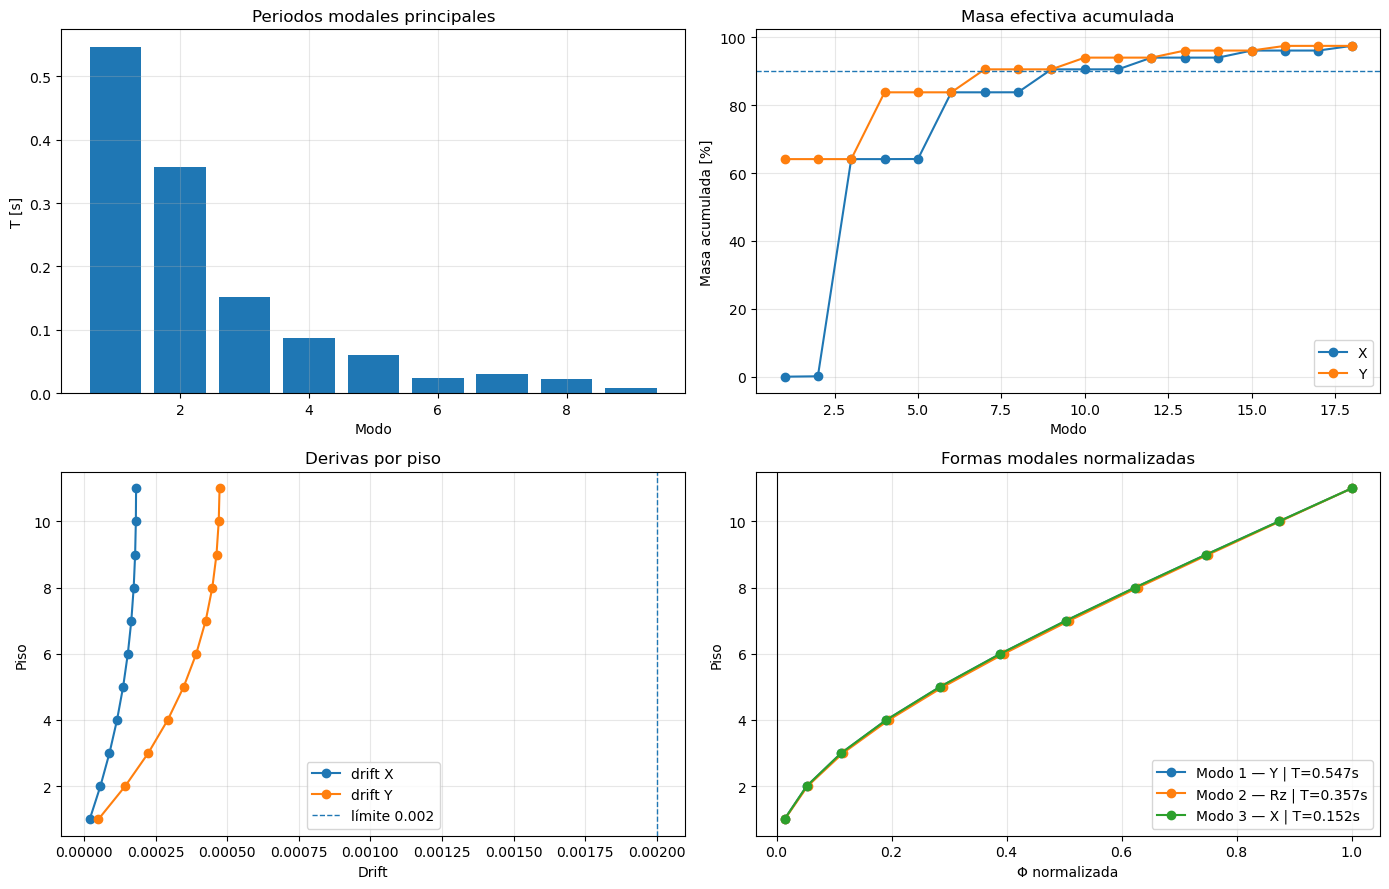

In [9]:
# ============================================================
# CELDA — AUDITORÍA FÍSICA DE UN CASO DEL DATASET v6
# Autónoma: solo requiere el archivo .h5
# Revisa:
# - ficha del caso
# - orden modal Y / T / X
# - masa efectiva acumulada
# - drift y cumplimiento
# - simetría de K y M
# - ortogonalidad modal Phiᵀ M Phi ≈ I
# - residual físico KΦ - ω²MΦ
# - gráficos modales principales
# ============================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── CONFIGURACIÓN ───────────────────────────────────────────
CASE_ID = 2100   # ← CAMBIA AQUÍ EL CASO A AUDITAR

# Si ya tienes H5_PATH definido en el notebook, se usa ese.
# Si no, busca automáticamente el último HDF5 v6.
try:
    H5_PATH
except NameError:
    OUT_DIR = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees")
    H5_PATH = sorted(
        OUT_DIR.glob("dataset_familyB_OPENSEES_v6_*.h5"),
        key=lambda p: p.stat().st_mtime
    )[-1]

print(f"Auditando HDF5: {H5_PATH}")
print(f"Caso ID: {CASE_ID}")

# ── FUNCIONES AUXILIARES ────────────────────────────────────
def decode_mode(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)

def check_ok(cond):
    return "OK ✓" if cond else "REVISAR ✗"

def classify_slot_expected(r):
    ciclo = r % 3
    if ciclo == 0:
        return "trans_Y"
    elif ciclo == 1:
        return "torsional"
    else:
        return "trans_X"

# ── CARGA DEL CASO ──────────────────────────────────────────
with h5py.File(H5_PATH, "r") as h5:
    features = [f.decode("utf-8") for f in h5["inputs/input_features"][:]]
    X = h5["inputs/X"][CASE_ID].astype(float)

    N = int(h5["scalars/N_pisos"][CASE_ID])
    cumple = bool(h5["scalars/cumple"][CASE_ID])

    T = h5["modal/T_r"][CASE_ID].astype(float)
    omega = h5["modal/omega_r"][CASE_ID].astype(float)
    mode_types = [decode_mode(m) for m in h5["modal/mode_types"][CASE_ID]]

    mass_part_x = h5["modal/mass_part_x"][CASE_ID].astype(float)
    mass_part_y = h5["modal/mass_part_y"][CASE_ID].astype(float)
    mass_acc_x = h5["modal/mass_acc_x"][CASE_ID].astype(float)
    mass_acc_y = h5["modal/mass_acc_y"][CASE_ID].astype(float)

    Phi_x = h5["modal/Phi_x"][CASE_ID].astype(float)
    Phi_y = h5["modal/Phi_y"][CASE_ID].astype(float)
    Phi_t = h5["modal/Phi_theta"][CASE_ID].astype(float)

    Ux = h5["response/Ux_m"][CASE_ID].astype(float)
    Uy = h5["response/Uy_m"][CASE_ID].astype(float)
    drift_x = h5["response/drift_x"][CASE_ID].astype(float)
    drift_y = h5["response/drift_y"][CASE_ID].astype(float)
    Vb_x = float(h5["response/Vb_x_kN"][CASE_ID])
    Vb_y = float(h5["response/Vb_y_kN"][CASE_ID])

    K = h5["stiffness/K_global"][CASE_ID].astype(float)
    M = h5["stiffness/M_global"][CASE_ID].astype(float)
    PhiG = h5["stiffness/Phi_global"][CASE_ID].astype(float)
    omega_pad = h5["stiffness/omega_pad"][CASE_ID].astype(float)

# ── RECORTE A GDL ACTIVOS ───────────────────────────────────
ndof = 3 * N
K_act = K[:ndof, :ndof]
M_act = M[:ndof, :ndof]
Phi_act = PhiG[:ndof, :ndof]
omega_act = omega_pad[:ndof]

# ── QA MODAL ────────────────────────────────────────────────
K_sym_err = np.linalg.norm(K_act - K_act.T) / (np.linalg.norm(K_act) + 1e-12)
M_sym_err = np.linalg.norm(M_act - M_act.T) / (np.linalg.norm(M_act) + 1e-12)

Mt = Phi_act.T @ M_act @ Phi_act
I = np.eye(ndof)
ortho_err = np.linalg.norm(Mt - I) / (np.linalg.norm(I) + 1e-12)

residuals = []
for r in range(ndof):
    phi = Phi_act[:, r]
    w = omega_act[r]
    if w <= 0 or np.linalg.norm(phi) < 1e-12:
        continue
    res = K_act @ phi - (w**2) * (M_act @ phi)
    den = np.linalg.norm(K_act @ phi) + 1e-12
    residuals.append(np.linalg.norm(res) / den)

residuals = np.array(residuals)
res_med = np.median(residuals)
res_max = np.max(residuals)

# ── MASA 90% ────────────────────────────────────────────────
n90 = None
for r in range(len(T)):
    if mass_acc_x[r] >= 0.90 and mass_acc_y[r] >= 0.90:
        n90 = r + 1
        break

if n90 is None:
    n90 = len(T)

# ── DRIFTS ──────────────────────────────────────────────────
dx_max = np.max(drift_x[:N])
dy_max = np.max(drift_y[:N])
piso_dx = np.argmax(drift_x[:N]) + 1
piso_dy = np.argmax(drift_y[:N]) + 1

# ── FICHA DEL CASO ──────────────────────────────────────────
print("\n" + "="*75)
print(f"FICHA TÉCNICA — CASO {CASE_ID}")
print("="*75)

print("\nINPUTS")
for name, value in zip(features, X):
    print(f"  {name:<20}: {value:.4g}")

print("\nRESULTADOS GLOBALES")
print(f"  N pisos              : {N}")
print(f"  Cumple NCh433         : {'CUMPLE ✅' if cumple else 'NO CUMPLE ❌'}")
print(f"  Vb_x / Vb_y           : {Vb_x:.2f} / {Vb_y:.2f} kN")
print(f"  Drift X máximo        : {dx_max:.6f} piso {piso_dx} | {check_ok(dx_max <= 0.002)}")
print(f"  Drift Y máximo        : {dy_max:.6f} piso {piso_dy} | {check_ok(dy_max <= 0.002)}")
print(f"  Ux techo              : {Ux[N-1]*100:.3f} cm")
print(f"  Uy techo              : {Uy[N-1]*100:.3f} cm")

print("\nMODOS PRINCIPALES")
for r in range(min(9, len(T))):
    esperado = classify_slot_expected(r)
    print(
        f"  M{r+1:<2} | T={T[r]:.4f} s | tipo={mode_types[r]:<12} "
        f"| esperado={esperado:<10} "
        f"| γx={mass_part_x[r]*100:5.1f}% γy={mass_part_y[r]*100:5.1f}% "
        f"| Σx={mass_acc_x[r]*100:5.1f}% Σy={mass_acc_y[r]*100:5.1f}%"
    )

print("\nMASA EFECTIVA")
print(f"  Modos para ≥90% X/Y   : {n90}")
print(f"  Masa acumulada X      : {mass_acc_x[n90-1]*100:.2f}%")
print(f"  Masa acumulada Y      : {mass_acc_y[n90-1]*100:.2f}%")
print(f"  Check masa ≥90%       : {check_ok(mass_acc_x[n90-1] >= 0.90 and mass_acc_y[n90-1] >= 0.90)}")

print("\nQA FÍSICO K/M/Φ")
print(f"  Simetría K            : {K_sym_err:.3e} | {check_ok(K_sym_err < 1e-6)}")
print(f"  Simetría M            : {M_sym_err:.3e} | {check_ok(M_sym_err < 1e-10)}")
print(f"  Ortogonalidad ΦᵀMΦ    : {ortho_err:.3e} | {check_ok(ortho_err < 1e-5)}")
print(f"  Residual modal med    : {res_med:.3e}")
print(f"  Residual modal max    : {res_max:.3e} | {check_ok(res_max < 5e-2)}")

print("\nCRÍTICA AUTOMÁTICA")
if T[2] < 0.20 and N >= 10:
    print("  ⚠ T3 traslacional X es muy bajo para un edificio alto. Revisar posible sobre-rigidez en X.")
else:
    print("  ✓ T3 no activa alerta fuerte de sobre-rigidez.")

if "torsional" in mode_types[1]:
    print("  ✓ La torsión aparece como segundo modo. Es plausible si la planta es alargada o la rigidez torsional es baja.")
else:
    print("  ⚠ El segundo modo no aparece como torsional. Revisar orden modal real del caso.")

if T[0] > T[2]*2.5:
    print("  ⚠ Diferencia fuerte entre flexibilidad Y y X. Revisar anisotropía de rigidez.")
else:
    print("  ✓ Relación entre T1 y T3 no parece extrema.")

print("="*75)

# ── GRÁFICOS ────────────────────────────────────────────────
pisos = np.arange(1, N+1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Periodos
axes[0,0].bar(np.arange(1, 10), T[:9])
axes[0,0].set_title("Periodos modales principales")
axes[0,0].set_xlabel("Modo")
axes[0,0].set_ylabel("T [s]")
axes[0,0].grid(True, alpha=0.3)

# Masa acumulada
axes[0,1].plot(np.arange(1, len(T)+1), mass_acc_x*100, marker="o", label="X")
axes[0,1].plot(np.arange(1, len(T)+1), mass_acc_y*100, marker="o", label="Y")
axes[0,1].axhline(90, linestyle="--", linewidth=1)
axes[0,1].set_title("Masa efectiva acumulada")
axes[0,1].set_xlabel("Modo")
axes[0,1].set_ylabel("Masa acumulada [%]")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Drifts
axes[1,0].plot(drift_x[:N], pisos, marker="o", label="drift X")
axes[1,0].plot(drift_y[:N], pisos, marker="o", label="drift Y")
axes[1,0].axvline(0.002, linestyle="--", linewidth=1, label="límite 0.002")
axes[1,0].set_title("Derivas por piso")
axes[1,0].set_xlabel("Drift")
axes[1,0].set_ylabel("Piso")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Formas modales 1-3
for r, color, label in [
    (0, "tab:blue", "Modo 1 — Y"),
    (1, "tab:purple", "Modo 2 — Rz"),
    (2, "tab:red", "Modo 3 — X"),
]:
    if r % 3 == 0:
        phi = Phi_y[:N, r]
    elif r % 3 == 1:
        phi = Phi_t[:N, r]
    else:
        phi = Phi_x[:N, r]

    phi = phi / (np.max(np.abs(phi)) + 1e-12)
    axes[1,1].plot(phi, pisos, marker="o", label=f"{label} | T={T[r]:.3f}s")

axes[1,1].axvline(0, color="black", linewidth=0.8)
axes[1,1].set_title("Formas modales normalizadas")
axes[1,1].set_xlabel("Φ normalizada")
axes[1,1].set_ylabel("Piso")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELDA — AUDITORÍA PKL vs HDF5 PARA UN CASO
# Verifica que la configuración geométrica usada en OpenSees
# coincida con el caso guardado en el dataset HDF5
# ============================================================

import pickle
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

CASE_ID = 2100

PKL_PATH = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\final\dataset_familyB_cases_20260505_0005.pkl")
H5_PATH  = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\dataset_familyB_OPENSEES_v6_20260518_0811.h5")

with open(PKL_PATH, "rb") as f:
    cases = pickle.load(f)

case = cases[CASE_ID]
params_pkl = case["params"]
wall_df = case["wall_df"]

with h5py.File(H5_PATH, "r") as h5:
    features = [x.decode("utf-8") for x in h5["inputs/input_features"][:]]
    X_h5 = h5["inputs/X"][CASE_ID]
    N_h5 = int(h5["scalars/N_pisos"][CASE_ID])
    T = h5["modal/T_r"][CASE_ID]
    mode_types = [x.decode("utf-8") if isinstance(x, bytes) else str(x) 
                  for x in h5["modal/mode_types"][CASE_ID]]

print("="*70)
print(f"AUDITORÍA PKL vs HDF5 — CASO {CASE_ID}")
print("="*70)

print("\n1) VARIABLES DE ENTRADA")
for name, value_h5 in zip(features, X_h5):
    if name in params_pkl:
        value_pkl = params_pkl[name]
        print(f"{name:<22} PKL={value_pkl:<10} | H5={value_h5:<10.4g}")
    else:
        print(f"{name:<22} PKL=NO DIRECTO | H5={value_h5:<10.4g}")

print("\n2) GEOMETRÍA DESDE PKL")
print(f"N_pisos          : {params_pkl['N_pisos']}")
print(f"Lx_m             : {params_pkl['Lx_m']:.3f} m")
print(f"Ly_m             : {params_pkl['Ly_m']:.3f} m")
print(f"h_story_m        : {params_pkl['h_story_m']:.3f} m")
print(f"H_total_m        : {params_pkl['H_total_m']:.3f} m")
print(f"Aspect ratio     : {params_pkl['Lx_m']/params_pkl['Ly_m']:.3f}")

print("\n3) MUROS DESDE PKL")
print(wall_df.groupby("group").size())

print("\n4) RESULTADO OPENSEES/HDF5")
print(f"N_pisos HDF5      : {N_h5}")
print(f"T1, T2, T3        : {T[0]:.4f}, {T[1]:.4f}, {T[2]:.4f} s")
print(f"Modo 1-3          : {mode_types[:3]}")

print("\n5) CHECK PRINCIPAL")
if int(params_pkl["N_pisos"]) == N_h5:
    print("OK ✓ El número de pisos coincide entre PKL y HDF5.")
else:
    print("REVISAR ✗ El número de pisos NO coincide.")

print("="*70)

AUDITORÍA PKL vs HDF5 — CASO 2100

1) VARIABLES DE ENTRADA
N_pisos                PKL=11         | H5=11        
n_unid_lado            PKL=3          | H5=3         
mods_por_depto         PKL=2          | H5=2         
activar_B2             PKL=1          | H5=1         
activar_B3             PKL=1          | H5=1         
L_mod_m                PKL=3.25       | H5=3.25      
prof_depto_m           PKL=7.4        | H5=7.4       
ancho_corredor_m       PKL=1.5        | H5=1.5       
L_nucleo_m             PKL=6.0        | H5=6         
B_nucleo_m             PKL=4.45       | H5=4.45      
h_story_m              PKL=2.9        | H5=2.9       
fc_MPa                 PKL=35         | H5=35        
gk_kN_m2               PKL=6.0        | H5=6         
t_muro_nucleo_m        PKL=0.25       | H5=0.25      
t_muro_borde_m         PKL=0.25       | H5=0.25      
t_muro_mid_m           PKL=0.2        | H5=0.2       
suelo                  PKL=D          | H5=3         
zona                   

AUDITORÍA DEL PATRÓN MODAL — CASO 2100

1) GEOMETRÍA GENERAL
  N pisos              : 11
  Lx x Ly              : 57.73 m x 16.34 m
  Lx/Ly                : 3.53
  h_story              : 2.90 m
  fc                   : 35 MPa
  E estimado            : 27806 MPa

2) CONTEO DE MUROS
group  orientacion
B1     X               3
       Y               4
B2     Y               2
B3     Y              14
B4     X               3
dtype: int64

3) RIGIDEZ GEOMÉTRICA PROXY
  Kx_proxy              : 1.025e+08
  Ky_proxy              : 7.917e+06
  Kx/Ky proxy           : 12.943
  Ktheta_proxy          : 4.897e+09

4) CENTRO DE RIGIDEZ APROXIMADO
  CM                    : (28.87, 8.17) m
  xCR para carga Y       : 28.89 m
  yCR para carga X       : 7.57 m
  ex = xCR - xCM         : 0.022 m
  ey = yCR - yCM         : -0.601 m

5) PERIODOS Y ORDEN MODAL
  M1  | trans_Y      | T=0.5468 s | γx=  0.0% | γy= 64.1% | Σx=  0.0% | Σy= 64.1%
  M2  | torsional    | T=0.3575 s | γx=  0.1% | γy=  0.0% | Σx=  0.

,n_muros,Kx_proxy,Ky_proxy,Ktheta_proxy,cx_prom,cy_prom,%Kx,%Ky,%Ktheta
group,,,,,,,,,
B1,7,1.454724e+04,204405.443,1.313994e+06,28.964,12.060,0.014,2.582,0.027
B2,2,1.183546e+03,5059108.458,4.178983e+09,28.866,8.172,0.001,63.901,85.342
B3,14,1.925890e+03,2651548.814,6.409184e+08,28.926,7.530,0.002,33.492,13.089
B4,3,1.024534e+08,2010.585,7.553034e+07,28.911,8.445,99.983,0.025,1.542


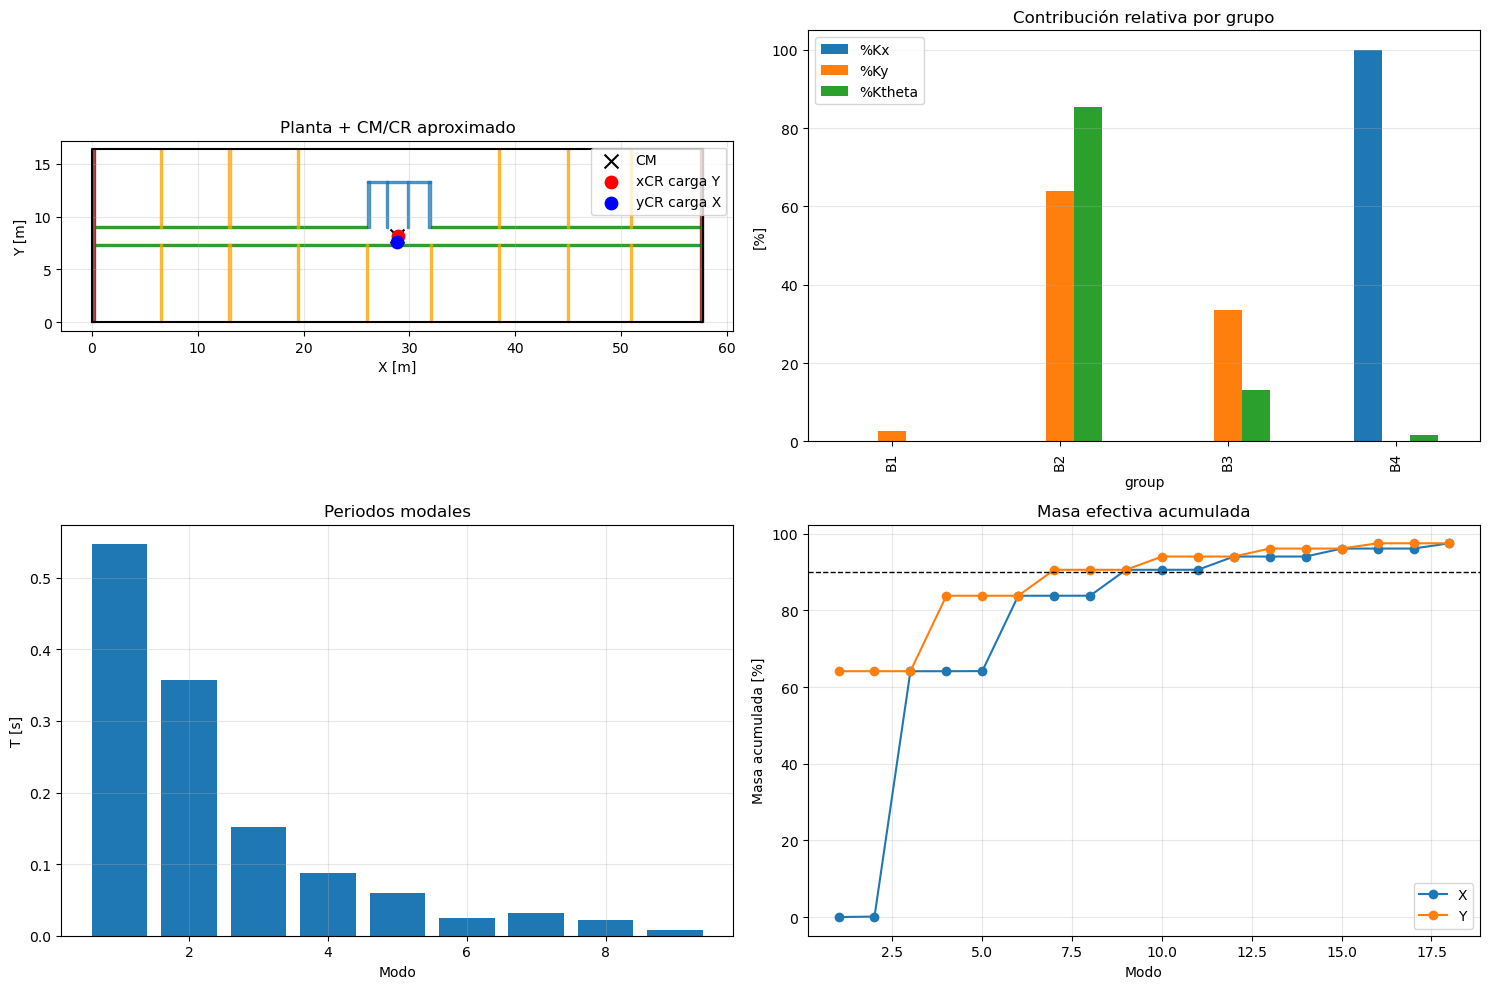

In [11]:
# ============================================================
# AUDITORÍA DEL PATRÓN MODAL — PKL + HDF5
# Objetivo:
# Explicar por qué el caso tiene patrón modal:
#   M1 = Y, M2 = torsión, M3 = X
#
# Revisa:
# 1) Geometría y distribución de muros desde PKL
# 2) Rigidez geométrica proxy en X, Y y torsión
# 3) Centro de rigidez aproximado vs CM
# 4) Periodos y razones de rigidez desde HDF5
# 5) Participación modal y masa efectiva
# 6) Diagnóstico físico automático
# ============================================================

import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── CONFIGURACIÓN ───────────────────────────────────────────
CASE_ID = 2100

PKL_PATH = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\final\dataset_familyB_cases_20260505_0005.pkl")
H5_PATH  = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\opensees\dataset_familyB_OPENSEES_v6_20260518_0811.h5")

# ── CARGA PKL ───────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    cases = pickle.load(f)

case = cases[CASE_ID]
params = case["params"]
wall_df = case["wall_df"].copy()

# ── CARGA HDF5 ──────────────────────────────────────────────
with h5py.File(H5_PATH, "r") as h5:
    N = int(h5["scalars/N_pisos"][CASE_ID])
    T = h5["modal/T_r"][CASE_ID].astype(float)
    omega = h5["modal/omega_r"][CASE_ID].astype(float)
    mode_types = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in h5["modal/mode_types"][CASE_ID]
    ]

    mass_part_x = h5["modal/mass_part_x"][CASE_ID].astype(float)
    mass_part_y = h5["modal/mass_part_y"][CASE_ID].astype(float)
    mass_acc_x  = h5["modal/mass_acc_x"][CASE_ID].astype(float)
    mass_acc_y  = h5["modal/mass_acc_y"][CASE_ID].astype(float)

    K = h5["stiffness/K_global"][CASE_ID].astype(float)
    M = h5["stiffness/M_global"][CASE_ID].astype(float)

# ── DATOS GENERALES ─────────────────────────────────────────
Lx = float(params["Lx_m"])
Ly = float(params["Ly_m"])
fc = float(params["fc_MPa"])
E_MPa = 4700 * np.sqrt(fc)

xCM = Lx / 2
yCM = Ly / 2

# ────────────────────────────────────────────────────────────
# 1) RIGIDEZ GEOMÉTRICA PROXY POR MURO
# ------------------------------------------------------------
# Para un muro rectangular en planta:
#   dimensión w = ancho en X
#   dimensión h = largo en Y
#
# Proxy de rigidez lateral:
#   Kx_proxy ~ Iy = h*w^3/12
#   Ky_proxy ~ Ix = w*h^3/12
#
# Esto NO reemplaza a OpenSees, pero sirve para explicar
# qué dirección está geométricamente más rigidizada.
# ────────────────────────────────────────────────────────────

wall_df["w"] = wall_df["w"].astype(float)
wall_df["h"] = wall_df["h"].astype(float)
wall_df["cx"] = wall_df["cx"].astype(float)
wall_df["cy"] = wall_df["cy"].astype(float)

wall_df["orientacion"] = np.where(wall_df["w"] >= wall_df["h"], "X", "Y")

wall_df["Ix_proxy_resiste_Y"] = wall_df["w"] * wall_df["h"]**3 / 12
wall_df["Iy_proxy_resiste_X"] = wall_df["h"] * wall_df["w"]**3 / 12

wall_df["Kx_proxy"] = E_MPa * wall_df["Iy_proxy_resiste_X"]
wall_df["Ky_proxy"] = E_MPa * wall_df["Ix_proxy_resiste_Y"]

# Brazo respecto al CM
wall_df["rx"] = wall_df["cx"] - xCM
wall_df["ry"] = wall_df["cy"] - yCM

# Proxy torsional: rigidez lateral * brazo²
wall_df["Ktheta_proxy"] = wall_df["Kx_proxy"] * wall_df["ry"]**2 + wall_df["Ky_proxy"] * wall_df["rx"]**2

Kx_proxy = wall_df["Kx_proxy"].sum()
Ky_proxy = wall_df["Ky_proxy"].sum()
Ktheta_proxy = wall_df["Ktheta_proxy"].sum()

# Centro de rigidez aproximado
xCR_y = (wall_df["Ky_proxy"] * wall_df["cx"]).sum() / (wall_df["Ky_proxy"].sum() + 1e-12)
yCR_x = (wall_df["Kx_proxy"] * wall_df["cy"]).sum() / (wall_df["Kx_proxy"].sum() + 1e-12)

ex = xCR_y - xCM
ey = yCR_x - yCM

# ────────────────────────────────────────────────────────────
# 2) RAZONES DINÁMICAS DESDE PERIODOS
# ------------------------------------------------------------
# Si las masas efectivas son comparables:
#   Kx/Ky ≈ (Ty/Tx)^2
# ────────────────────────────────────────────────────────────

T_Y = T[0]
T_Rz = T[1]
T_X = T[2]

ratio_Kx_Ky_modal = (T_Y / T_X)**2
ratio_Ktheta_Ky_modal = (T_Y / T_Rz)**2

ratio_Kx_Ky_proxy = Kx_proxy / (Ky_proxy + 1e-12)

# ────────────────────────────────────────────────────────────
# 3) RESUMEN
# ────────────────────────────────────────────────────────────

print("="*80)
print(f"AUDITORÍA DEL PATRÓN MODAL — CASO {CASE_ID}")
print("="*80)

print("\n1) GEOMETRÍA GENERAL")
print(f"  N pisos              : {N}")
print(f"  Lx x Ly              : {Lx:.2f} m x {Ly:.2f} m")
print(f"  Lx/Ly                : {Lx/Ly:.2f}")
print(f"  h_story              : {params['h_story_m']:.2f} m")
print(f"  fc                   : {fc:.0f} MPa")
print(f"  E estimado            : {E_MPa:.0f} MPa")

print("\n2) CONTEO DE MUROS")
print(wall_df.groupby(["group", "orientacion"]).size())

print("\n3) RIGIDEZ GEOMÉTRICA PROXY")
print(f"  Kx_proxy              : {Kx_proxy:.3e}")
print(f"  Ky_proxy              : {Ky_proxy:.3e}")
print(f"  Kx/Ky proxy           : {ratio_Kx_Ky_proxy:.3f}")
print(f"  Ktheta_proxy          : {Ktheta_proxy:.3e}")

print("\n4) CENTRO DE RIGIDEZ APROXIMADO")
print(f"  CM                    : ({xCM:.2f}, {yCM:.2f}) m")
print(f"  xCR para carga Y       : {xCR_y:.2f} m")
print(f"  yCR para carga X       : {yCR_x:.2f} m")
print(f"  ex = xCR - xCM         : {ex:.3f} m")
print(f"  ey = yCR - yCM         : {ey:.3f} m")

print("\n5) PERIODOS Y ORDEN MODAL")
for r in range(9):
    print(
        f"  M{r+1:<2} | {mode_types[r]:<12} | "
        f"T={T[r]:.4f} s | "
        f"γx={mass_part_x[r]*100:5.1f}% | "
        f"γy={mass_part_y[r]*100:5.1f}% | "
        f"Σx={mass_acc_x[r]*100:5.1f}% | "
        f"Σy={mass_acc_y[r]*100:5.1f}%"
    )

print("\n6) RAZONES DINÁMICAS DESDE PERIODOS")
print(f"  T_Y / T_X             : {T_Y/T_X:.2f}")
print(f"  Kx/Ky modal aprox      : {ratio_Kx_Ky_modal:.2f}")
print(f"  Ktheta/Ky modal aprox  : {ratio_Ktheta_Ky_modal:.2f}")

print("\n7) DIAGNÓSTICO AUTOMÁTICO")

if mode_types[0] == "trans_Y":
    print("  ✓ M1 en Y: la dirección Y es la más flexible del modelo.")
else:
    print("  ⚠ M1 no es Y. Revisar clasificación modal.")

if mode_types[1] == "torsional":
    print("  ✓ M2 torsional: la rigidez torsional es menor que la rigidez traslacional X.")
else:
    print("  ⚠ M2 no es torsional. Revisar patrón modal.")

if mode_types[2] == "trans_X":
    print("  ✓ M3 en X: la dirección X es la más rígida entre las traslacionales principales.")
else:
    print("  ⚠ M3 no es X. Revisar clasificación modal.")

if ratio_Kx_Ky_modal > 5:
    print("  ⚠ Alta anisotropía dinámica: X es mucho más rígido que Y.")
else:
    print("  ✓ La anisotropía X/Y no parece extrema.")

if abs(ex) > 0.05 * Lx or abs(ey) > 0.05 * Ly:
    print("  ⚠ Existe excentricidad relevante entre CM y rigidez aproximada. Puede favorecer torsión.")
else:
    print("  ✓ Excentricidad CM-CR baja. La torsión temprana podría venir más por baja rigidez torsional global que por excentricidad.")

if T_X < 0.20 and N >= 10:
    print("  ⚠ T_X muy bajo para edificio de 10+ pisos. Revisar posible sobre-rigidez en X.")
else:
    print("  ✓ T_X no activa alerta fuerte.")

print("="*80)

# ────────────────────────────────────────────────────────────
# 4) TABLA DE CONTRIBUCIÓN POR GRUPO
# ────────────────────────────────────────────────────────────

tabla_grupos = (
    wall_df
    .groupby("group")
    .agg(
        n_muros=("group", "size"),
        Kx_proxy=("Kx_proxy", "sum"),
        Ky_proxy=("Ky_proxy", "sum"),
        Ktheta_proxy=("Ktheta_proxy", "sum"),
        cx_prom=("cx", "mean"),
        cy_prom=("cy", "mean"),
    )
)

tabla_grupos["%Kx"] = 100 * tabla_grupos["Kx_proxy"] / (Kx_proxy + 1e-12)
tabla_grupos["%Ky"] = 100 * tabla_grupos["Ky_proxy"] / (Ky_proxy + 1e-12)
tabla_grupos["%Ktheta"] = 100 * tabla_grupos["Ktheta_proxy"] / (Ktheta_proxy + 1e-12)

display(tabla_grupos.round(3))

# ────────────────────────────────────────────────────────────
# 5) GRÁFICOS
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Planta con muros
colors = {
    "B1": "tab:blue",
    "B2": "darkred",
    "B3": "orange",
    "B4": "green",
}

ax = axes[0,0]
ax.plot([0, Lx, Lx, 0, 0], [0, 0, Ly, Ly, 0], color="black", lw=1.5)

for _, w in wall_df.iterrows():
    x0 = w["cx"] - w["w"]/2
    x1 = w["cx"] + w["w"]/2
    y0 = w["cy"] - w["h"]/2
    y1 = w["cy"] + w["h"]/2
    group = str(w["group"])
    ax.fill(
        [x0, x1, x1, x0],
        [y0, y0, y1, y1],
        color=colors.get(group, "gray"),
        alpha=0.7
    )

ax.scatter([xCM], [yCM], marker="x", s=100, color="black", label="CM")
ax.scatter([xCR_y], [yCM], marker="o", s=80, color="red", label="xCR carga Y")
ax.scatter([xCM], [yCR_x], marker="o", s=80, color="blue", label="yCR carga X")
ax.set_title("Planta + CM/CR aproximado")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend()

# Rigidez proxy por grupo
ax = axes[0,1]
tabla_grupos[["%Kx", "%Ky", "%Ktheta"]].plot(kind="bar", ax=ax)
ax.set_title("Contribución relativa por grupo")
ax.set_ylabel("[%]")
ax.grid(True, axis="y", alpha=0.3)

# Periodos
ax = axes[1,0]
ax.bar(np.arange(1, 10), T[:9])
ax.set_title("Periodos modales")
ax.set_xlabel("Modo")
ax.set_ylabel("T [s]")
ax.grid(True, alpha=0.3)

# Masa efectiva
ax = axes[1,1]
ax.plot(np.arange(1, len(T)+1), mass_acc_x*100, marker="o", label="X")
ax.plot(np.arange(1, len(T)+1), mass_acc_y*100, marker="o", label="Y")
ax.axhline(90, color="black", linestyle="--", lw=1)
ax.set_title("Masa efectiva acumulada")
ax.set_xlabel("Modo")
ax.set_ylabel("Masa acumulada [%]")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()